## 0. Install & Mount

## 1. Imports & Reproducibility

In [ ]:
import os, json, random, time, copy, gc, hashlib, platform
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler
import segmentation_models_pytorch as smp
from tqdm import tqdm
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except TypeError:
    torch.use_deterministic_algorithms(True)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {vram_gb:.1f} GB")
print(f"PyTorch: {torch.__version__}")
print(f"cuDNN benchmark: {torch.backends.cudnn.benchmark}")
print(f"cuDNN deterministic: {torch.backends.cudnn.deterministic}")

/home/annie/miniconda3/envs/CIL/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA GeForce RTX 3060
VRAM   : 11.6 GB
PyTorch: 2.11.0+cu130
cuDNN benchmark: False
cuDNN deterministic: True


## 2. Configuration

In [ ]:
DATA_ROOT = "./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault"
IMAGES_2D_DIR  = os.path.join(DATA_ROOT, "images")
MASKS_2D_DIR   = os.path.join(DATA_ROOT, "masks")
METADATA_PATH  = os.path.join(DATA_ROOT, "metadata.json")
SPLIT_PATH     = os.path.join(DATA_ROOT, "volume_split.json")
CHECKPOINT_DIR = os.path.join(DATA_ROOT, "checkpoints_baseline")
LOG_DIR        = os.path.join(DATA_ROOT, "logs_baseline")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

IGNORE_INDEX = 255

TRAIN_CFG = {
    "batch_size"  : 16,
    "lr"          : 3e-4,
    "n_epochs"    : 50,
    "save_every"  : 10,
    "val_ratio"   : 0.2,
    "num_workers" : 2,
    "loss_alpha"  : 0.5,
    "encoder"     : "resnet34",
    "pretrained"  : "imagenet",
    "num_classes" : 14,
    "seed"        : 42,
}

# --- MiB Hyperparameters ---
ALPHA_PER_TASK = {
    1: 0.0,
    2: 0.3,
    3: 0.5,
    4: 0.6,
}
MIB_TEMPERATURE  = 2.0
MIB_ALPHA = None
CIL_EVAL_EVERY   = 10
KD_COLLAPSE_RATIO_WARN = 1e-6

METHOD_NAME = "MiB"
EVAL_PROTOCOL = "val-selection + sealed-test-final"
EVAL_SPLIT_NAME = "val"
METRIC_LEVEL = "2D slice-level"
PREPROCESSING_VERSION = "processed_2d_ct_v2_canonical_mib"

_alpha_str = "adaptive_" + "_".join(
    f"t{k}a{str(v).replace('.','p')}" for k, v in ALPHA_PER_TASK.items()
)
EXPERIMENT_ID = (
    f"mibstyle_{TRAIN_CFG['encoder']}_seed{TRAIN_CFG['seed']}_"
    f"T{str(MIB_TEMPERATURE).replace('.', 'p')}_{_alpha_str}"
)

TASK_ORGANS = {
    1: [6, 7],
    2: [1, 2, 3, 8],
    3: [4, 9, 10, 11],
    4: [5, 12, 13],
}
ORGAN_NAMES = {
    0:  "Background",
    1:  "Spleen (Lach)",
    2:  "Right Kidney (Than P)",
    3:  "Left Kidney (Than T)",
    4:  "Gallbladder (Tui mat)",
    5:  "Esophagus (Thuc quan)",
    6:  "Liver (Gan)",
    7:  "Stomach (Da day)",
    8:  "Aorta (DM chu)",
    9:  "IVC (TM chu duoi)",
    10: "Portal Vein (TM cua)",
    11: "Pancreas (Tuy)",
    12: "Right Adrenal (TTT P)",
    13: "Left Adrenal (TTT T)",
}

ALL_PAST_ORGANS = {
    1: [6, 7],
    2: [6, 7, 1, 2, 3, 8],
    3: [6, 7, 1, 2, 3, 8, 4, 9, 10, 11],
    4: [6, 7, 1, 2, 3, 8, 4, 9, 10, 11, 5, 12, 13],
}

random.seed(TRAIN_CFG["seed"])
np.random.seed(TRAIN_CFG["seed"])
torch.manual_seed(TRAIN_CFG["seed"])

print("Config:")
print(f"   MiB alpha (per-task): {ALPHA_PER_TASK}")
print(f"   MiB temperature : {MIB_TEMPERATURE}")
print(f"   method          : {METHOD_NAME}")
print(f"   eval protocol   : {EVAL_PROTOCOL} ({METRIC_LEVEL})")
print(f"   experiment id   : {EXPERIMENT_ID}")
print(f"   CIL eval every  : {CIL_EVAL_EVERY}")
for k, v in TRAIN_CFG.items():
    print(f"   {k:15s}: {v}")

print("\\nTask definitions:")
for task_id, organs in TASK_ORGANS.items():
    print(f"   Task {task_id}: {[ORGAN_NAMES[o] for o in organs]}")


Config:
   MiB alpha (per-task): {1: 0.0, 2: 0.3, 3: 0.5, 4: 0.6}
   MiB temperature : 2.0
   method          : MiB
   eval protocol   : val-selection + sealed-test-final (2D slice-level)
   experiment id   : mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6
   CIL eval every  : 10
   batch_size     : 16
   lr             : 0.0003
   n_epochs       : 50
   save_every     : 10
   val_ratio      : 0.2
   num_workers    : 2
   loss_alpha     : 0.5
   encoder        : resnet34
   pretrained     : imagenet
   num_classes    : 14
   seed           : 42
\nTask definitions:
   Task 1: ['Liver (Gan)', 'Stomach (Da day)']
   Task 2: ['Spleen (Lach)', 'Right Kidney (Than P)', 'Left Kidney (Than T)', 'Aorta (DM chu)']
   Task 3: ['Gallbladder (Tui mat)', 'IVC (TM chu duoi)', 'Portal Vein (TM cua)', 'Pancreas (Tuy)']
   Task 4: ['Esophagus (Thuc quan)', 'Right Adrenal (TTT P)', 'Left Adrenal (TTT T)']


## 3. Dataset & Data Utilities

In [ ]:
import os, json, random, time, copy, gc, hashlib, platform
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.cuda.amp import autocast, GradScaler
import segmentation_models_pytorch as smp
from tqdm import tqdm

# ============================================================
# Helper Functions (synced with LwF)
# ============================================================

def remap_mask_for_task(mask_npy, task_id, ignore_index=255):
    task_organs = TASK_ORGANS[task_id]
    new_mask = np.zeros_like(mask_npy, dtype=np.uint8)
    for organ_id in task_organs:
        new_mask[mask_npy == organ_id] = organ_id
    return new_mask


def get_slices_for_task(metadata, task_id):
    task_organs = set(TASK_ORGANS[task_id])
    return [r for r in metadata if task_organs & set(r["organs_present"])]


def log_vram(label=""):
    if not torch.cuda.is_available():
        return
    used  = torch.cuda.memory_allocated() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    pct   = used / total * 100
    tag   = "WARNING" if pct > 85 else "OK"
    print(f"   {tag} VRAM {label}: {used:.2f}/{total:.1f} GB ({pct:.0f}%)")


def force_cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def save_baselines(task_baselines, log_dir, method="mib"):
    bl_path = os.path.join(log_dir, f"{method}_per_organ_baselines.json")
    serializable = {}
    for oid, dice in task_baselines.items():
        serializable[str(oid)] = {
            "organ_id": oid,
            "organ_name": ORGAN_NAMES.get(oid, f"Organ {oid}"),
            "baseline_dice": round(dice, 6) if not np.isnan(dice) else None,
        }
    with open(bl_path, 'w') as f:
        json.dump(serializable, f, indent=2)
    print(f"  Baselines saved: {bl_path} ({len(serializable)} organs)")
    return bl_path


def load_baselines(log_dir, method="mib"):
    bl_path = os.path.join(log_dir, f"{method}_per_organ_baselines.json")
    if not os.path.exists(bl_path):
        raise FileNotFoundError(f"Baselines not found: {bl_path}")
    with open(bl_path, 'r') as f:
        raw = json.load(f)
    task_baselines = {}
    for _, entry in raw.items():
        oid = entry["organ_id"]
        dice = entry["baseline_dice"]
        if dice is not None:
            task_baselines[oid] = dice
    print(f"  Baselines loaded: {bl_path} ({len(task_baselines)} organs)")
    for oid, d in sorted(task_baselines.items()):
        print(f"    {ORGAN_NAMES.get(oid, f'Organ {oid}'):30s}: {d:.4f}")
    return task_baselines


def create_three_way_split(all_records, val_ratio=0.10, test_ratio=0.30, seed=42):
    from collections import defaultdict as _dd
    assert 0.0 < val_ratio < 1.0
    assert 0.0 < test_ratio < 1.0
    assert val_ratio + test_ratio < 1.0

    vol_to_recs = _dd(list)
    for rec in all_records:
        vol_to_recs[rec["volume_id"]].append(rec)

    vol_ids = sorted(vol_to_recs.keys())
    rng = random.Random(seed)
    rng.shuffle(vol_ids)

    n_total = len(vol_ids)
    n_test = max(1, int(round(n_total * test_ratio)))
    n_val = max(1, int(round(n_total * val_ratio)))
    if n_test + n_val >= n_total:
        raise ValueError("Not enough volumes for requested train/val/test split.")

    test_vols = set(vol_ids[:n_test])
    val_vols = set(vol_ids[n_test:n_test + n_val])
    train_vols = set(vol_ids[n_test + n_val:])

    train_records = [r for r in all_records if r["volume_id"] in train_vols]
    val_records = [r for r in all_records if r["volume_id"] in val_vols]
    test_records = [r for r in all_records if r["volume_id"] in test_vols]

    print(f"  [3-way Split] Total volumes: {n_total}, train={len(train_vols)}, val={len(val_vols)}, test={len(test_vols)}")
    print(f"  [3-way Split] Val volumes : {sorted(val_vols)}")
    print(f"  [3-way Split] Test volumes: {sorted(test_vols)}")
    return train_vols, val_vols, test_vols, train_records, val_records, test_records


def stratified_split_by_volume(all_records, val_ratio=0.2, seed=42):
    from collections import defaultdict as _dd
    vol_to_recs = _dd(list)
    for rec in all_records:
        vol_to_recs[rec["volume_id"]].append(rec)

    vol_ids = sorted(vol_to_recs.keys())
    rng = random.Random(seed)
    rng.shuffle(vol_ids)

    n_val = max(1, int(len(vol_ids) * val_ratio))
    val_vols = set(vol_ids[:n_val])
    print(f"  [Split] Total volumes: {len(vol_ids)}, val={n_val}, train={len(vol_ids)-n_val}")
    print(f"  [Split] Val volumes  : {sorted(val_vols)}")

    train_records = [r for vid in vol_ids if vid not in val_vols for r in vol_to_recs[vid]]
    val_records = [r for vid in val_vols for r in vol_to_recs[vid]]
    return train_records, val_records


def load_volume_split(split_path, metadata):
    with open(split_path, "r") as f:
        split = json.load(f)
    missing = [k for k in ["train_vol_ids", "val_vol_ids", "test_vol_ids"] if k not in split]
    if missing:
        raise KeyError(f"volume_split.json missing required sealed-test keys: {missing}")

    train_vol_ids = set(split["train_vol_ids"])
    val_vol_ids = set(split["val_vol_ids"])
    test_vol_ids = set(split["test_vol_ids"])
    assert train_vol_ids.isdisjoint(val_vol_ids), "Volume split leakage: train and val overlap"
    assert train_vol_ids.isdisjoint(test_vol_ids), "Volume split leakage: train and sealed test overlap"
    assert val_vol_ids.isdisjoint(test_vol_ids), "Volume split leakage: val and sealed test overlap"

    print(f"  [load_volume_split] Loaded: {split_path}")
    print(f"  [load_volume_split] Seed={split.get('seed','?')}, "
          f"val_ratio={split.get('val_ratio','?')}, test_ratio={split.get('test_ratio','?')}, "
          f"created_by={split.get('created_by','?')}")
    print(f"  [load_volume_split] Train={len(train_vol_ids)} vols, Val={len(val_vol_ids)} vols, Test={len(test_vol_ids)} vols")
    print(f"  [load_volume_split] Val volumes : {sorted(val_vol_ids)}")
    print(f"  [load_volume_split] Test volumes: {sorted(test_vol_ids)}")

    train_records = [r for r in metadata if r["volume_id"] in train_vol_ids]
    val_records = [r for r in metadata if r["volume_id"] in val_vol_ids]
    test_records = [r for r in metadata if r["volume_id"] in test_vol_ids]
    assert train_records and val_records and test_records, "Empty train/val/test records after loading split."
    return train_vol_ids, val_vol_ids, test_vol_ids, train_records, val_records, test_records

def format_dice_table(dice_dict, task_organs, epoch=None):
    header = f"  {'Epoch':>6}" if epoch is not None else ""
    print(f"\n{header}  {'Organ':30s}  {'Dice':>8}  {'Status':>10}")
    print("  " + "-" * 58)
    valid_dices = []
    for organ_id in task_organs:
        dice = dice_dict.get(organ_id, float('nan'))
        name = ORGAN_NAMES.get(organ_id, f"Organ {organ_id}")
        if not np.isnan(dice):
            valid_dices.append(dice)
            status = "Good" if dice >= 0.7 else ("Fair" if dice >= 0.5 else "Poor")
            ep_str = f"{epoch:6d}" if epoch is not None else ""
            print(f"  {ep_str}  {name:30s}  {dice:8.4f}  {status}")
        else:
            ep_str = f"{epoch:6d}" if epoch is not None else ""
            print(f"  {ep_str}  {name:30s}  {'N/A':>8}  (not in batch)")
    if valid_dices:
        mean_dice = np.mean(valid_dices)
        print("  " + "=" * 58)
        ep_str = f"{epoch:6d}" if epoch is not None else ""
        print(f"  {ep_str}  {'Mean Dice':30s}  {mean_dice:8.4f}")
    return np.mean(valid_dices) if valid_dices else 0.0


class BTCVDataset(Dataset):
    def __init__(self, records, images_dir, masks_dir,
                 task_id=None, augment=False, ignore_index=255):
        self.records      = records
        self.images_dir   = images_dir
        self.masks_dir    = masks_dir
        self.task_id      = task_id
        self.augment      = augment
        self.ignore_index = ignore_index

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        ct_npy   = np.load(os.path.join(self.images_dir, rec["filename"]))
        mask_npy = np.load(os.path.join(self.masks_dir, rec["filename"]))

        if self.task_id is not None:
            mask_npy = remap_mask_for_task(mask_npy, self.task_id, self.ignore_index)

        if self.augment:
            ct_npy, mask_npy = self._augment(ct_npy, mask_npy)

        ct_tensor   = torch.from_numpy(ct_npy.copy()).unsqueeze(0)
        mask_tensor = torch.from_numpy(mask_npy.astype(np.int64))
        return ct_tensor, mask_tensor

    def _augment(self, ct, mask):
        if np.random.random() > 0.5:
            ct   = np.fliplr(ct).copy()
            mask = np.fliplr(mask).copy()
        if np.random.random() > 0.5:
            ct   = np.flipud(ct).copy()
            mask = np.flipud(mask).copy()
        k = np.random.randint(0, 4)
        if k > 0:
            ct   = np.rot90(ct, k).copy()
            mask = np.rot90(mask, k).copy()
        return ct, mask




# ============================================================
# Integrity / reproducibility helpers
# ============================================================

def _json_default(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, set):
        return sorted(obj)
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")


def stable_json_hash(payload):
    encoded = json.dumps(payload, sort_keys=True, separators=(",", ":"), default=_json_default).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()


def file_sha256(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()


def records_checksum(records):
    normalized = []
    for r in records:
        normalized.append({
            "filename": r.get("filename"),
            "volume_id": r.get("volume_id"),
            "organs_present": sorted([int(x) for x in r.get("organs_present", [])]),
        })
    normalized = sorted(normalized, key=lambda x: (str(x["volume_id"]), str(x["filename"])))
    return stable_json_hash(normalized)


def split_checksum(train_vol_ids, val_vol_ids, test_vol_ids=None):
    return stable_json_hash({
        "train_vol_ids": sorted(list(train_vol_ids)),
        "val_vol_ids": sorted(list(val_vol_ids)),
        "test_vol_ids": sorted(list(test_vol_ids or [])),
    })



def config_hash(split_hash=None):
    payload = {
        "train_cfg": TRAIN_CFG,
        "alpha_per_task": ALPHA_PER_TASK,
        "mib_temperature": MIB_TEMPERATURE,
        "task_organs": TASK_ORGANS,
        "preprocessing_version": PREPROCESSING_VERSION,
        "method": METHOD_NAME,
        "protocol": EVAL_PROTOCOL,
        "metric_level": METRIC_LEVEL,
        "split_checksum": split_hash,
    }
    return stable_json_hash(payload)


# Task 1 checkpoints that predate the sealed-test protocol are whitelisted for
# legacy-compatible loading. All Task2+ checkpoints are always strict.
_LEGACY_TASK1_WHITELIST = True   # set False to enforce strict mode globally

def assert_checkpoint_compatible(state, checkpoint_path,
                                 expected_split_checksum, expected_config_hash, expected_seed,
                                 task_id=None):
    is_task1_legacy = (
        _LEGACY_TASK1_WHITELIST
        and (task_id == 1 or state.get("task_id") == 1)
    )

    # Alpha migration flag — Task 2 checkpoint was trained with single MIB_ALPHA=0.3
    # before per-task alpha was introduced. Split/seed are still valid.
    is_alpha_migration = (
        (task_id == 2 or state.get("task_id") == 2)
        and state.get("mib_alpha") == 0.3   # fingerprint của checkpoint cũ
    )

    missing = [k for k in ["split_checksum", "config_hash", "seed"] if k not in state]

    if missing:
        if is_task1_legacy:
            print(
                f"""
  [LEGACY WARNING] *** Task 1 checkpoint {checkpoint_path} ***
  [LEGACY WARNING] Checkpoint predates the sealed-test protocol.
  [LEGACY WARNING] Missing metadata fields: {missing}
  [LEGACY WARNING] This checkpoint was trained before split_checksum / config_hash / seed locking was enforced.
  [LEGACY WARNING] Task 1 results are INDICATIVE ONLY and may contain checkpoint-selection bias.
  [LEGACY WARNING] Proceeding with legacy-compatible load (no metadata injected).
"""
            )
            return  # legacy allow — no field injection
        else:
            raise AssertionError(
                f"Checkpoint {checkpoint_path} is missing run-lock metadata {missing}. "
                f"Task {task_id or state.get('task_id', '?')} checkpoints must be strict. "
                "Refusing stale/unsafe checkpoint reuse."
            )

    # ── Strict validation (all Task2+ and whitelisted Task1 with metadata) ──
    if state["split_checksum"] != expected_split_checksum:
        raise AssertionError(
            f"Checkpoint split checksum MISMATCH for {checkpoint_path}:\n"
            f"  stored  : {state['split_checksum']}\n"
            f"  expected: {expected_split_checksum}\n"
            "This checkpoint was trained on a different data split. "
            "Results would not be comparable."
        )

    if state["config_hash"] != expected_config_hash:
        if is_alpha_migration:
            _stored_alpha  = state.get("mib_alpha", "?")
            _next_task_id  = (task_id or state.get("task_id", 2)) + 1
            _next_alpha    = ALPHA_PER_TASK.get(_next_task_id, "?")
            # config_hash lệch vì alpha scheme thay đổi từ single → per-task.
            # Data split, seed, model arch không đổi → an toàn để tiếp tục.
            print(
                f"\n  [ALPHA MIGRATION WARNING] *** {checkpoint_path} ***"
                f"\n  [ALPHA MIGRATION WARNING] config_hash lệch do alpha scheme migration."
                f"\n  [ALPHA MIGRATION WARNING]   stored  : {state['config_hash']}"
                f"\n  [ALPHA MIGRATION WARNING]   expected: {expected_config_hash}"
                f"\n  [ALPHA MIGRATION WARNING] Split checksum và seed đã khớp — an toàn."
                f"\n  [ALPHA MIGRATION WARNING] Task {task_id} checkpoint (alpha={_stored_alpha})"
                f" được dùng làm"
                f"\n  [ALPHA MIGRATION WARNING] teacher/base cho Task {_next_task_id}"
                f" (alpha={_next_alpha})."
                f"\n  [ALPHA MIGRATION WARNING] Proceeding with alpha-migration-compatible load.\n"
            )
            # Không raise — tiếp tục kiểm tra seed rồi return
        else:
            raise AssertionError(
                f"Checkpoint config hash MISMATCH for {checkpoint_path}:\n"
                f"  stored  : {state['config_hash']}\n"
                f"  expected: {expected_config_hash}\n"
                "Configuration changed since checkpoint was saved. "
                "Refusing potentially incompatible reuse."
            )

    if int(state["seed"]) != int(expected_seed):
        raise AssertionError(
            f"Checkpoint seed MISMATCH for {checkpoint_path}: "
            f"{state['seed']} != {expected_seed}. "
            "Seed change would break reproducibility."
        )

def assert_metric_unit_interval(value, name, allow_nan=True):
    if allow_nan and (value is None or np.isnan(value)):
        return
    assert np.isfinite(value), f"{name} is not finite: {value}"
    assert 0.0 <= float(value) <= 1.0, f"{name} outside [0, 1]: {value}"


def assert_valid_metric_dict(metric_dict, name, allow_nan=True):
    for k, v in metric_dict.items():
        assert_metric_unit_interval(v, f"{name}[{k}]", allow_nan=allow_nan)


def assert_valid_mask_tensor(mask, num_classes, ignore_index=255, name="mask"):
    assert mask.dtype in (torch.int64, torch.int32, torch.int16, torch.uint8), f"{name} dtype invalid: {mask.dtype}"
    unique = torch.unique(mask.detach())
    invalid = unique[((unique < 0) | ((unique >= num_classes) & (unique != ignore_index)))]
    assert invalid.numel() == 0, f"{name} contains invalid labels: {invalid.detach().cpu().tolist()[:20]}"


def checkpoint_hash(path):
    if path is None or not os.path.exists(path):
        return None
    return file_sha256(path)


def cache_token(experiment_id, split_hash, seed, task_id, temperature, teacher_hash):
    teacher_short = (teacher_hash or "no_teacher")[:12]
    temp_str = str(temperature).replace(".", "p")
    return f"{experiment_id}_split{split_hash[:12]}_seed{seed}_task{task_id}_T{temp_str}_teacher{teacher_short}"


def expected_cache_metadata(task_id, train_records, split_hash, seed, teacher_ckpt_path,
                            temperature, image_size, old_organs, soft_targets_path,
                            pseudo_masks_path):
    teacher_sha = checkpoint_hash(teacher_ckpt_path)
    n = len(train_records)
    h, w = image_size
    return {
        "method": METHOD_NAME,
        "protocol": EVAL_PROTOCOL,
        "metric_level": METRIC_LEVEL,
        "experiment_id": EXPERIMENT_ID,
        "task_id": int(task_id),
        "seed": int(seed),
        "split_name": EVAL_SPLIT_NAME,
        "split_checksum": split_hash,
        "train_records_checksum": records_checksum(train_records),
        "teacher_checkpoint_path": teacher_ckpt_path,
        "teacher_checkpoint_hash": teacher_sha,
        "temperature": float(temperature),
        "image_size": [int(h), int(w)],
        "num_slices": int(n),
        "num_classes": int(TRAIN_CFG["num_classes"]),
        "old_organs": [int(o) for o in old_organs],
        "preprocessing_version": PREPROCESSING_VERSION,
        "soft_targets_path": soft_targets_path,
        "pseudo_masks_path": pseudo_masks_path,
        "soft_targets_shape": [int(n), len([0] + [int(o) for o in old_organs]), int(h), int(w)],
        "pseudo_masks_shape": [int(n), int(h), int(w)],
        "soft_targets_dtype": "float16",
        "pseudo_masks_dtype": "int16",
    }


def write_cache_metadata(metadata_path, metadata):
    metadata = dict(metadata)
    metadata["soft_targets_sha256"] = file_sha256(metadata["soft_targets_path"])
    metadata["pseudo_masks_sha256"] = file_sha256(metadata["pseudo_masks_path"])
    metadata["created_at_unix"] = time.time()
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2, default=_json_default)
    print(f"  Cache metadata saved: {metadata_path}")
    return metadata


def verify_cache_or_raise(metadata_path, expected, strict_hash=True):
    if not os.path.exists(metadata_path):
        raise FileNotFoundError(f"Cache metadata missing: {metadata_path}")
    with open(metadata_path, "r") as f:
        meta = json.load(f)

    required_exact = [
        "experiment_id", "task_id", "seed", "split_checksum", "train_records_checksum",
        "teacher_checkpoint_hash", "temperature", "image_size", "num_slices",
        "num_classes", "old_organs", "preprocessing_version", "soft_targets_shape",
        "pseudo_masks_shape", "soft_targets_dtype", "pseudo_masks_dtype",
    ]
    mismatches = []
    for key in required_exact:
        if meta.get(key) != expected.get(key):
            mismatches.append((key, meta.get(key), expected.get(key)))
    if mismatches:
        details = "; ".join(f"{k}: cached={a} expected={b}" for k, a, b in mismatches[:5])
        raise ValueError(f"Cache metadata mismatch: {details}")

    for path_key in ["soft_targets_path", "pseudo_masks_path"]:
        if not os.path.exists(meta[path_key]):
            raise FileNotFoundError(f"Cache data missing: {meta[path_key]}")

    soft = np.load(meta["soft_targets_path"], mmap_mode="r")
    pseudo = np.load(meta["pseudo_masks_path"], mmap_mode="r")
    assert list(soft.shape) == meta["soft_targets_shape"], f"soft_targets shape mismatch: {soft.shape}"
    assert list(pseudo.shape) == meta["pseudo_masks_shape"], f"pseudo_masks shape mismatch: {pseudo.shape}"
    assert str(soft.dtype) == meta["soft_targets_dtype"], f"soft_targets dtype mismatch: {soft.dtype}"
    assert str(pseudo.dtype) == meta["pseudo_masks_dtype"], f"pseudo_masks dtype mismatch: {pseudo.dtype}"
    del soft, pseudo

    if strict_hash:
        soft_hash = file_sha256(meta["soft_targets_path"])
        pseudo_hash = file_sha256(meta["pseudo_masks_path"])
        if soft_hash != meta.get("soft_targets_sha256"):
            raise ValueError("soft_targets SHA256 mismatch")
        DRIVE_ROOT     = "/content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault"
IMAGES_2D_DIR  = f"{DRIVE_ROOT}/data/processed/images"
MASKS_2D_DIR   = f"{DRIVE_ROOT}/data/processed/masks"
METADATA_PATH  = f"{DRIVE_ROOT}/data/processed/metadata.json"
CHECKPOINT_DIR = f"{DRIVE_ROOT}/checkpoints_baseline"
LOG_DIR        = f"{DRIVE_ROOT}/logs_baseline"
SPLIT_PATH     = f"{DRIVE_ROOT}/data/processed/volume_split.json"if pseudo_hash != meta.get("pseudo_masks_sha256"):
            raise ValueError("pseudo_masks SHA256 mismatch")

    print("  Cache metadata/checksum verified: match")
    return meta


def get_rng_state():
    return {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
        "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
    }


def _coerce_torch_rng_state(raw):
    """
    Legacy checkpoints may store torch RNG state as list or numpy array instead of
    torch.ByteTensor. This function converts any such legacy format to a proper
    torch.uint8 CPU tensor, which is what torch.set_rng_state() requires.

    Raises ValueError immediately if the conversion produces an invalid tensor
    (wrong dtype or zero-length) so failures are never silently swallowed.
    """
    if isinstance(raw, torch.Tensor):
        if raw.dtype != torch.uint8:
            raise ValueError(
                f"[RNG] torch_cpu RNG state tensor has unexpected dtype {raw.dtype}; "
                "expected torch.uint8. Cannot safely restore RNG state."
            )
        return raw.cpu()

    # Legacy: list of ints (serialised via pickle/json)
    if isinstance(raw, list):
        arr = torch.tensor(raw, dtype=torch.uint8)
        print(
            "  [RNG WARNING] torch_cpu RNG state was stored as a list (legacy checkpoint). "
            "Converted to torch.uint8 tensor. Reproducibility is best-effort only."
        )
    # Legacy: numpy array
    elif hasattr(raw, 'dtype'):  # numpy array
        arr = torch.from_numpy(raw.astype('uint8'))
        print(
            "  [RNG WARNING] torch_cpu RNG state was stored as a numpy array (legacy checkpoint). "
            "Converted to torch.uint8 tensor. Reproducibility is best-effort only."
        )
    else:
        raise TypeError(
            f"[RNG] Unsupported torch_cpu RNG state type: {type(raw)}. "
            "Expected torch.Tensor, list, or numpy.ndarray."
        )

    if arr.numel() == 0:
        raise ValueError("[RNG] Converted torch_cpu RNG state tensor is empty.")
    if arr.dtype != torch.uint8:
        raise ValueError(f"[RNG] Coerced tensor dtype is {arr.dtype}; expected torch.uint8.")
    return arr


def restore_rng_state(state):
    """
    Restore Python / NumPy / Torch-CPU / CUDA RNG states from a checkpoint dict.

    Backward-compatible: handles legacy checkpoints where torch_cpu state was
    serialised as a list or numpy array instead of a ByteTensor.
    Fails loudly on any format it cannot safely convert — never silently skips.
    """
    if not state:
        print("  [RNG] No RNG state found in checkpoint; continuing from current RNG state.")
        return

    # ── Python RNG ──────────────────────────────────────────────
    if "python" in state and state["python"] is not None:
        random.setstate(state["python"])
    else:
        print("  [RNG WARNING] Python RNG state missing in checkpoint.")

    # ── NumPy RNG ───────────────────────────────────────────────
    if "numpy" in state and state["numpy"] is not None:
        np.random.set_state(state["numpy"])
    else:
        print("  [RNG WARNING] NumPy RNG state missing in checkpoint.")

    # ── Torch CPU RNG ────────────────────────────────────────----
    if "torch_cpu" in state and state["torch_cpu"] is not None:
        torch_state = _coerce_torch_rng_state(state["torch_cpu"])
        # Hard assertions before calling set_rng_state
        assert torch.is_tensor(torch_state),             f"[RNG] torch_cpu state is not a Tensor after coercion: {type(torch_state)}"
        assert torch_state.dtype == torch.uint8,             f"[RNG] torch_cpu state dtype is {torch_state.dtype} after coercion; expected torch.uint8"
        torch.set_rng_state(torch_state)
    else:
        print("  [RNG WARNING] Torch CPU RNG state missing in checkpoint.")

    # ── CUDA RNG ─────────────────────────────────────────────────
    if torch.cuda.is_available() and state.get("cuda") is not None:
        cuda_states = state["cuda"]
        # Each per-device state must also be a ByteTensor; apply same coercion.
        if isinstance(cuda_states, list):
            coerced = [_coerce_torch_rng_state(s) for s in cuda_states]
            torch.cuda.set_rng_state_all(coerced)
        else:
            print("  [RNG WARNING] CUDA RNG state has unexpected structure; skipping CUDA restore.")
    elif torch.cuda.is_available():
        print("  [RNG WARNING] CUDA RNG state not found in checkpoint.")

    print("  [RNG] Restored Python/NumPy/Torch/CUDA RNG state from checkpoint.")


def update_run_manifest(manifest_path, **updates):
    manifest = {}
    if os.path.exists(manifest_path):
        with open(manifest_path, "r") as f:
            manifest = json.load(f)
    manifest.update(updates)
    manifest["updated_at_unix"] = time.time()
    with open(manifest_path, "w") as f:
        json.dump(manifest, f, indent=2, default=_json_default)
    print(f"  Manifest updated: {manifest_path}")
    return manifest


print("Helpers + BTCVDataset + integrity helpers ready!")


Helpers + BTCVDataset + integrity helpers ready!


## 4. Losses & Metrics

In [ ]:
# ============================================================
# Model + Loss + Metrics (giong het LwF / EWC)
# ============================================================

def build_unet(num_classes=14, encoder="resnet34", pretrained="imagenet"):
    return smp.Unet(
        encoder_name    = encoder,
        encoder_weights = pretrained,
        in_channels     = 1,
        classes         = num_classes,
        activation      = None,
    )


class TaskDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5, ignore_index=255):
        super().__init__()
        self.smooth       = smooth
        self.ignore_index = ignore_index

    def forward(self, logits, target, task_organs):
        probs = F.softmax(logits, dim=1)
        valid = (target != self.ignore_index).float()
        dice_list = []
        for c in task_organs:
            pred_c = probs[:, c] * valid
            true_c = (target == c).float() * valid
            intsec = (pred_c * true_c).sum(dim=(1, 2))
            union  = pred_c.sum(dim=(1, 2)) + true_c.sum(dim=(1, 2))
            dice   = (2 * intsec + self.smooth) / (union + self.smooth)
            dice_list.append(1 - dice.mean())
        return torch.stack(dice_list).mean()


class MiBUnbiasedCELoss(nn.Module):
    """
    MiB Unbiased Cross-Entropy Loss (Cermelli et al., CVPR 2020).
    For pixels where target == 0 (background), the probability of
    background includes probability mass from all old classes.
    For pixels where target != 0, standard cross-entropy is used.
    """
    def __init__(self, old_organs, ignore_index=255):
        super().__init__()
        self.old_organs = list(old_organs)
        self.ignore_index = ignore_index

    def forward(self, logits, target, old_organs=None):
        # Allow dynamic old_organs override (for flexibility)
        old_organs_use = old_organs if old_organs is not None else self.old_organs
        valid = (target != self.ignore_index)
        if not valid.any():
            return logits.sum() * 0.0

        probs = F.softmax(logits, dim=1)  # (B, C, H, W)
        loss_list = []

        # Background pixels: target == 0 AND valid
        bg_mask = (target == 0) & valid
        if bg_mask.any():
            # Background prob = prob[0] + sum(prob[old_organs])
            bg_prob = probs[:, 0]
            if len(old_organs_use) > 0:
                old_idx = torch.tensor(old_organs_use, dtype=torch.long, device=logits.device)
                bg_prob = bg_prob + probs[:, old_idx].sum(dim=1)
            bg_prob = bg_prob.clamp(min=1e-7)
            loss_bg = -torch.log(bg_prob)[bg_mask]
            loss_list.append(loss_bg)

        # Foreground pixels: target != 0 AND valid
        fg_mask = (target != 0) & valid
        if fg_mask.any():
            # Standard CE on foreground pixels using F.cross_entropy per pixel
            logits_fg = logits.permute(0, 2, 3, 1).reshape(-1, logits.shape[1])[fg_mask.reshape(-1)]
            target_fg = target.reshape(-1)[fg_mask.reshape(-1)]
            loss_fg = F.cross_entropy(logits_fg, target_fg, reduction='none')
            loss_list.append(loss_fg)

        if not loss_list:
            return logits.sum() * 0.0
        return torch.cat(loss_list).mean()


class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5, ignore_index=255, old_organs=None):
        super().__init__()
        self.alpha        = alpha
        self.ignore_index = ignore_index
        self.old_organs   = list(old_organs) if old_organs is not None else []
        self.ce           = MiBUnbiasedCELoss(old_organs=self.old_organs, ignore_index=ignore_index)
        self.dice         = TaskDiceLoss(ignore_index=ignore_index)

    def forward(self, logits, target, task_organs, old_organs=None):
        old_organs_use = old_organs if old_organs is not None else self.old_organs
        loss_ce   = self.ce(logits, target, old_organs=old_organs_use)
        loss_dice = self.dice(logits, target, task_organs)
        total     = self.alpha * loss_ce + (1 - self.alpha) * loss_dice
        return total, loss_ce.item(), loss_dice.item()


def compute_iou_per_organ(pred, target, organ_ids, ignore_index=255):
    valid = (target != ignore_index)
    iou_dict = {}
    inter_dict = {}
    union_iou_dict = {}
    for organ_id in organ_ids:
        pred_o = (pred == organ_id) & valid
        true_o = (target == organ_id) & valid
        inter = (pred_o & true_o).sum().item()
        union = pred_o.sum().item() + true_o.sum().item() - inter
        inter_dict[organ_id] = inter
        union_iou_dict[organ_id] = union
        if union > 0:
            iou_dict[organ_id] = inter / union
        else:
            iou_dict[organ_id] = float('nan')
    return iou_dict, inter_dict, union_iou_dict


def init_new_classifier_weights(model, task_id, noise_std=1e-5):
    seg_head = model.segmentation_head
    last_conv = None
    for m in seg_head.modules():
        if isinstance(m, (torch.nn.Conv2d, torch.nn.Linear)):
            last_conv = m

    if last_conv is None:
        print("  [init_new_weights] WARNING: could not find segmentation head conv layer")
        return

    new_organs = TASK_ORGANS[task_id]
    n_new = len(new_organs)

    with torch.no_grad():
        # MiB paper: chia background weight cho tổng số classes (N_old + N_new + 1)
        n_old = TRAIN_CFG["num_classes"] - 1 - len(new_organs)  # trừ background và new organs
        n_total = n_old + len(new_organs) + 1  # +1 cho background
        divided_weight = last_conv.weight[0] / n_total
        divided_bias = last_conv.bias[0] / n_total if last_conv.bias is not None else None

        for organ_id in new_organs:
            last_conv.weight[organ_id] = divided_weight.clone()
            if last_conv.bias is not None:
                last_conv.bias[organ_id] = divided_bias.clone()
            # Thêm nhiễu nhỏ để phá vỡ đối xứng
            if noise_std > 0:
                last_conv.weight[organ_id] += torch.randn_like(last_conv.weight[organ_id]) * noise_std
                if last_conv.bias is not None:
                    last_conv.bias[organ_id] += torch.randn_like(last_conv.bias[organ_id]) * noise_std

    print(f"  [init_new_weights] Initialized Task {task_id} organs {new_organs} "
      f"from background weights divided by {n_total} "
      f"(n_old={n_old}, n_new={len(new_organs)}, +1 bg) (noise_std={noise_std})")


print("Model + Loss + Metrics ready! (MiBUnbiasedCELoss)")

Model + Loss + Metrics ready! (MiBUnbiasedCELoss)


## 5. MiB Core Components

> **Background Shift Fix**  
> In LwF, pixels with `gt == 0` (true background) are trained with label 0.  
> But if a past organ was present there, the teacher knows it → use teacher's argmax as pseudo-label.  
> This prevents the new task's optimizer from pushing past-class logits toward background.
>
> Formally:  
> `ỹ(x) = argmax_c(f_old(x))` if `c ∈ C_old` and `gt(x) == 0`  
> `ỹ(x) = gt(x)` otherwise

In [ ]:
# ============================================================
# MiB Canonical Soft Target + Pseudo-Label Generation (disk-streaming)
# ============================================================
# Canonical MiB knowledge distillation (Cermelli et al., CVPR 2020):
# full 14-class softmax on teacher logits, then slice to old_channels.
# Cache reuse is allowed only after metadata, split checksum, shape, dtype, and
# file hash verification.
# ============================================================

@torch.no_grad()
def generate_soft_targets_mib(teacher_model, dataloader, old_organs,
                              temperature, device, ignore_index=255,
                              soft_targets_path=None, pseudo_masks_path=None,
                              metadata_path=None, cache_metadata=None):
    """
    Create disk-backed soft targets (float16) and pseudo masks (int16).
    Implements canonical MiB knowledge distillation:
      - Full 14-class softmax on teacher logits, then slice to old_channels
      - soft_targets sum < 1.0 (correct: remaining mass = new class probability)
      - Teacher renormalized to sum=1 inside MiBKDLoss before KL divergence
    Returns path strings; tensors are intentionally not accumulated in RAM.
    """
    assert soft_targets_path is not None and pseudo_masks_path is not None,         "soft_targets_path and pseudo_masks_path are required."
    assert metadata_path is not None and cache_metadata is not None,         "metadata_path and cache_metadata are required for cache integrity."

    teacher_model.eval()
    total_slices = len(dataloader.dataset)
    if total_slices <= 0:
        raise ValueError("Cannot generate cache for an empty dataset.")

    sample_ct, sample_mask = dataloader.dataset[0]
    H, W = int(sample_ct.shape[-2]), int(sample_ct.shape[-1])
    num_classes = int(TRAIN_CFG["num_classes"])

    assert cache_metadata["task_id"] >= 2, "MiB-style cache should only be generated for incremental tasks."
    assert cache_metadata["num_slices"] == total_slices, "Cache metadata num_slices mismatch."
    assert cache_metadata["image_size"] == [H, W], "Cache metadata image_size mismatch."

    old_channels = [0] + list(old_organs)
    n_old = len(old_channels)
    soft_shape = (total_slices, n_old, H, W)
    pseudo_shape = (total_slices, H, W)
    assert cache_metadata["soft_targets_shape"] == list(soft_shape)
    assert cache_metadata["pseudo_masks_shape"] == list(pseudo_shape)

    soft_size_gb = (np.prod(soft_shape) * np.dtype("float16").itemsize) / (1024**3)
    print(f"      old_channels : {old_channels} (len={n_old})")
    pseudo_size_gb = (np.prod(pseudo_shape) * np.dtype("int16").itemsize) / (1024**3)
    print("    [MiB-style] Creating verified memmap cache:")
    print(f"      soft_targets : {soft_size_gb:.2f} GB -> {soft_targets_path}")
    print(f"      pseudo_masks : {pseudo_size_gb:.2f} GB -> {pseudo_masks_path}")

    soft_mmap = np.lib.format.open_memmap(
        soft_targets_path, mode="w+", dtype="float16", shape=soft_shape
    )
    pseudo_mmap = np.lib.format.open_memmap(
        pseudo_masks_path, mode="w+", dtype="int16", shape=pseudo_shape
    )

    slice_idx = 0
    valid_values = set([0, ignore_index] + list(range(num_classes)))
    for ct_batch, mask_batch in tqdm(dataloader, desc="    MiB-style pseudo-labels"):
        ct_batch = ct_batch.to(device, non_blocking=True)
        assert mask_batch.ndim == 3 and mask_batch.shape[-2:] == (H, W), "mask_batch shape mismatch"

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = teacher_model(ct_batch)
        assert logits.ndim == 4 and logits.shape[1] == num_classes, "teacher logits shape mismatch"

        logits_f32 = logits.float()
        # Canonical MiB: full 14-class softmax, then slice to old_channels
        # Deviation from prior code: softmax is over ALL classes first so that
        # old-class probabilities are not artificially inflated by a partial denominator.
        old_ch_tensor = torch.tensor(old_channels, dtype=torch.long, device=logits.device)
        soft_probs_full = torch.softmax(logits_f32 / temperature, dim=1)  # full 14-class softmax
        soft_probs = soft_probs_full[:, old_ch_tensor]                     # slice AFTER softmax
        assert soft_probs.sum(dim=1).max().item() <= 1.0 + 1e-5, \
            "full-softmax slice must sum <= 1.0"
        assert soft_probs.sum(dim=1).min().item() >= 0.0, \
            "probabilities must be non-negative"
        teacher_pred = logits_f32.argmax(dim=1).cpu()

        pseudo_masks = mask_batch.clone()
        bg_pixels = (mask_batch == 0)
        is_old_organ = torch.zeros_like(teacher_pred, dtype=torch.bool)
        for c in old_organs:
            is_old_organ |= (teacher_pred == int(c))
        relabel_mask = bg_pixels & is_old_organ
        pseudo_masks[relabel_mask] = teacher_pred[relabel_mask]

        uniques = set(int(v) for v in torch.unique(pseudo_masks).cpu().tolist())
        unexpected = sorted(uniques - valid_values)
        assert not unexpected, f"Unexpected pseudo-mask values: {unexpected[:10]}"
        assert_valid_mask_tensor(pseudo_masks, num_classes, ignore_index, name="generated pseudo_masks")

        batch_size = ct_batch.size(0)
        end = slice_idx + batch_size
        assert end <= total_slices, "Cache write would exceed allocated memmap."
        soft_mmap[slice_idx:end] = soft_probs.half().cpu().numpy()
        pseudo_mmap[slice_idx:end] = pseudo_masks.numpy().astype(np.int16)
        slice_idx = end

    assert slice_idx == total_slices, f"Wrote {slice_idx}/{total_slices} slices."
    soft_mmap.flush()
    pseudo_mmap.flush()
    del soft_mmap, pseudo_mmap, soft_probs, teacher_pred, pseudo_masks
    force_cleanup()

    write_cache_metadata(metadata_path, cache_metadata)
    verify_cache_or_raise(metadata_path, cache_metadata, strict_hash=True)
    print(f"    Generated {total_slices} verified pseudo-labels (disk-streaming, RAM safe)")
    return soft_targets_path, pseudo_masks_path


print("generate_soft_targets_mib ready! (verified disk-streaming cache)")

generate_soft_targets_mib ready! (verified disk-streaming cache)


In [ ]:
# ============================================================
# BTCVDatasetWithMiB — verified mmap-backed dataset
# ============================================================

class BTCVDatasetWithMiB(Dataset):
    def __init__(self, records, images_dir, masks_dir,
                 soft_targets_path, pseudo_masks_path,
                 task_id, augment=False, ignore_index=255,
                 metadata_path=None, expected_metadata=None):
        self.records = records
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.task_id = task_id
        self.augment = augment
        self.ignore_index = ignore_index

        if metadata_path is not None and expected_metadata is not None:
            verify_cache_or_raise(metadata_path, expected_metadata, strict_hash=True)

        self.soft_targets_mmap = np.load(soft_targets_path, mmap_mode="r")
        self.pseudo_masks_mmap = np.load(pseudo_masks_path, mmap_mode="r")

        n = len(self.records)
        assert self.task_id == expected_metadata["task_id"] if expected_metadata is not None else True
        assert self.soft_targets_mmap.shape[0] == n, "soft_targets length does not match records"
        assert self.pseudo_masks_mmap.shape[0] == n, "pseudo_masks length does not match records"
        assert self.soft_targets_mmap.dtype == np.float16, f"soft_targets dtype mismatch: {self.soft_targets_mmap.dtype}"
        assert self.pseudo_masks_mmap.dtype == np.int16, f"pseudo_masks dtype mismatch: {self.pseudo_masks_mmap.dtype}"
        # soft_targets now has shape (N, n_old_channels, H, W) not (N, num_classes, H, W)
        # n_old_channels = len([0] + old_organs), validated via metadata
        self._n_old = self.soft_targets_mmap.shape[1]  # store for __getitem__

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        ct_npy = np.load(os.path.join(self.images_dir, rec["filename"]))

        pseudo_npy = np.array(self.pseudo_masks_mmap[idx]).astype(np.int64)
        st_npy = np.array(self.soft_targets_mmap[idx])
        assert pseudo_npy.shape == ct_npy.shape[-2:], "pseudo mask/image shape mismatch"
        assert st_npy.shape[1:] == ct_npy.shape[-2:], "soft target/image shape mismatch"
        # st_npy shape: (n_old_channels, H, W) — only old channels, already softmaxed
        st = torch.from_numpy(st_npy)

        if self.augment:
            ct_npy, pseudo_npy, st = self._augment(ct_npy, pseudo_npy, st)

        ct_tensor = torch.from_numpy(ct_npy.copy()).unsqueeze(0)
        pseudo_tensor = torch.from_numpy(pseudo_npy.astype(np.int64))
        return ct_tensor, pseudo_tensor, st

    def _augment(self, ct, pseudo, st):
        if np.random.random() > 0.5:
            ct = np.fliplr(ct).copy()
            pseudo = np.fliplr(pseudo).copy()
            st = torch.flip(st, [2])

        if np.random.random() > 0.5:
            ct = np.flipud(ct).copy()
            pseudo = np.flipud(pseudo).copy()
            st = torch.flip(st, [1])

        k = np.random.randint(0, 4)
        if k > 0:
            ct = np.rot90(ct, k).copy()
            pseudo = np.rot90(pseudo, k).copy()
            st = torch.rot90(st, k, [1, 2])

        st = st.contiguous()
        return ct, pseudo, st


print("BTCVDatasetWithMiB ready! (verified mmap + synced augmentation)")

BTCVDatasetWithMiB ready! (verified mmap + synced augmentation)


## 6. MiB KD Loss

In [ ]:
# ============================================================
# MiB Canonical KD Loss — same normalization as LwF KDLoss
# ============================================================
# KL divergence over old-class channels with MiB-style pseudo-mask filtering.
# Teacher probabilities are renormalized to sum=1 before KL (required because
# full-softmax slice no longer sums to 1). bgKD uses only student p[0] (no new
# organ aggregation). Normalized per-pixel (B×H×W) to match LwF's scale.
# ============================================================

class MiBKDLoss(nn.Module):
    def __init__(self, temperature=2.0, ignore_index=255):
        super().__init__()
        self.T = temperature
        self.ignore_index = ignore_index

    def forward(self, student_logits, soft_targets, pseudo_masks, old_channels):
        """
        Args:
            student_logits : (B, 14, H, W) logits thô của học sinh
            soft_targets   : (B, n_old, H, W) xác suất mềm của giáo viên trên old_channels (full softmax, slice, renorm bên trong)
            pseudo_masks   : (B, H, W) mặt nạ đã được gán lại kiểu MiB
            old_channels   : [0, ...] danh sách ID lớp cũ (gồm cả nền)
        """
        B, C, H, W = student_logits.shape
        n_old = len(old_channels)   # = 1 + len(old_organs)

        # Lọc pixel không bị bỏ qua
        valid = (pseudo_masks != self.ignore_index)
        if not valid.any():
            return student_logits.sum() * 0.0

        # ----- 1. Xác suất toàn phần của học sinh (softmax trên toàn bộ 14 lớp) -----
        stu_probs = F.softmax(student_logits.float(), dim=1)   # (B, C, H, W)

        # ----- 2. Xây dựng phân phối học sinh trên {bgKD} ∪ old_organs -----
        # bgKD = prob nền (0) only — canonical MiB does NOT aggregate new-organ probs
        # into the background channel on the student side (that caused double penalty
        # on plasticity in the prior partial-KL approximation).
        bgKD = stu_probs[:, 0].clone()  # background channel only, no new_organs

        # Xác suất của các lớp cũ (không bao gồm nền thật, chỉ các cơ quan cũ)
        old_organs_ids = old_channels[1:]   # bỏ chỉ số 0
        stu_old_probs = stu_probs[:, old_organs_ids]   # (B, n_old-1, H, W)

        # Ghép thành vector phân phối học sinh: [bgKD, old_organs...]
        stu_dist = torch.cat([bgKD.unsqueeze(1), stu_old_probs], dim=1)   # (B, n_old, H, W)

        # ----- 3. Chuẩn hóa lại để đảm bảo tổng bằng 1 (chống lỗi số) -----
        stu_dist = stu_dist / (stu_dist.sum(dim=1, keepdim=True).clamp(min=1e-7))

        # ----- 4. KL divergence với giáo viên -----
        # Đưa về dạng phẳng
        N_pixels = B * H * W
        stu_flat = stu_dist.permute(0,2,3,1).reshape(-1, n_old)   # (N_pixels, n_old)
        tgt_flat = soft_targets.permute(0,2,3,1).reshape(-1, n_old)   # (N_pixels, n_old)
        valid_flat = valid.reshape(-1)

        stu_flat = stu_flat[valid_flat]
        tgt_flat = tgt_flat[valid_flat]

        if stu_flat.numel() == 0:
            return student_logits.sum() * 0.0

        # Chuyển sang float32 (đã float ở trên, nhưng nhắc lại)
        stu_flat = stu_flat.float()
        tgt_flat = tgt_flat.float()

        # Renormalize teacher to valid probability distribution (sums to 1)
        # Required because full-softmax slice no longer sums to 1
        tgt_sum = tgt_flat.sum(dim=1, keepdim=True).clamp(min=1e-7)
        tgt_flat = tgt_flat / tgt_sum

        # One-time diagnostic print to confirm distributions after renorm
        if not hasattr(self, '_logged'):
            print(f"  [KD CHECK] tgt_flat sum: min={tgt_flat.sum(dim=1).min():.4f} "
                  f"max={tgt_flat.sum(dim=1).max():.4f} (should be ≈1.0 after renorm)")
            stu_dist_flat = stu_dist.permute(0, 2, 3, 1).reshape(-1, stu_dist.shape[1])
            print(f"  [KD CHECK] stu_dist sum: min={stu_dist_flat[valid_flat].sum(dim=1).min():.4f} "
              f"max={stu_dist_flat[valid_flat].sum(dim=1).max():.4f} (should be ≈1.0)")
            self._logged = True

        # Kẹp giáo viên an toàn
        tgt_flat = tgt_flat.clamp(min=1e-7)

        # KL divergence: KL(teacher || student) = sum(teacher * log(teacher/student))
        # Dùng log-softmax trên student? Ở đây stu_dist đã là xác suất, nên cần log.
        # Chú ý: stu_dist đã chuẩn hóa, nên dùng log trực tiếp.
        stu_log = torch.log(stu_flat.clamp(min=1e-7))

        kd_loss = F.kl_div(
            stu_log,
            tgt_flat,
            reduction='batchmean',
            log_target=False
        ) * (self.T ** 2)

        # Kiểm tra NaN/Inf
        if torch.isnan(kd_loss) or torch.isinf(kd_loss):
            raise RuntimeError(
                f"[KD] KD loss is NaN/Inf. stu_log range: [{stu_log.min():.4f}, {stu_log.max():.4f}]"
            )
        return kd_loss

print(f"MiBKDLoss ready! (T={MIB_TEMPERATURE}, canonical MiB KL, teacher renorm, bgKD=p[0] only)")

MiBKDLoss ready! (T=2.0, canonical MiB KL, teacher renorm, bgKD=p[0] only)


## 7. Trainer

In [ ]:
# ============================================================
# MiBTrainer — synced structure with LwFTrainer
# ============================================================

class MiBTrainer:
    def __init__(self, model, optimizer, criterion, kd_criterion,
                 scheduler, device, task_id, task_organs, old_organs,
                 checkpoint_dir, log_dir, mib_alpha=1.0,
                 save_every=10, ignore_index=255, cil_eval_every=10):
        self.model          = model
        self.optimizer      = optimizer
        self.criterion      = criterion
        self.kd_criterion   = kd_criterion
        self.scheduler      = scheduler
        self.device         = device
        self.task_id        = task_id
        self.task_organs    = list(task_organs)
        self.all_learned    = list(ALL_PAST_ORGANS[task_id])
        self.old_organs     = list(old_organs)
        self.old_channels   = [0] + self.old_organs
        self.checkpoint_dir = checkpoint_dir
        self.log_dir        = log_dir
        self.mib_alpha      = mib_alpha
        self.save_every     = save_every
        self.ignore_index   = ignore_index
        self.cil_eval_every = cil_eval_every

        self.best_val_dice  = 0.0
        self.best_cil_dice  = 0.0
        self.miou_history   = []
        self.history        = {
            "train_loss": [], "val_loss": [],
            "val_dice": [], "lr": [],
            "kd_loss": [], "seg_loss": [],
            "kd_seg_ratio": [],
            "cil_dice": [],
            "kd_ratio_min": [],
        }

        self.min_kd_ratio = float('inf')
        self.use_amp = (device.type == 'cuda')
        self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)

        print(f"  MiBTrainer created ({METHOD_NAME}):")
        print(f"    Task {task_id}: {[ORGAN_NAMES[o] for o in self.task_organs]}")
        print(f"    Old organs: {[ORGAN_NAMES[o] for o in self.old_organs]}")
        print(f"    Alpha={mib_alpha}, CIL eval every {cil_eval_every} epochs")
        print(f"    AMP (Mixed Precision): {self.use_amp}")

    def train_epoch(self, loader):
        self.model.train()
        total_loss = total_seg = total_kd = 0.0
        n_batches = 0

        for ct_batch, pseudo_mask_batch, st_batch in loader:
            ct_batch          = ct_batch.to(self.device, non_blocking=True)
            pseudo_mask_batch = pseudo_mask_batch.to(self.device, non_blocking=True)
            st_batch          = st_batch.to(self.device, non_blocking=True)

            self.optimizer.zero_grad(set_to_none=True)
            assert_valid_mask_tensor(pseudo_mask_batch, TRAIN_CFG["num_classes"], self.ignore_index, name="train pseudo_mask_batch")

            # Chỉ bọc phần sinh logits trong autocast
            with torch.amp.autocast("cuda", enabled=self.use_amp):
                logits = self.model(ct_batch)

            # Từ đây trở đi, tất cả tính toán đều dùng float32
            loss_seg, _, _ = self.criterion(logits.float(), pseudo_mask_batch, self.task_organs,
                                            old_organs=self.old_organs)

            if self.kd_criterion is not None and len(self.old_channels) > 1:
                loss_kd = self.kd_criterion(logits, st_batch, pseudo_mask_batch, self.old_channels)
            else:
                loss_kd = logits.sum() * 0.0

            loss = loss_seg + self.mib_alpha * loss_kd   # ← giờ đây ở ngoài autocast, là float32
            assert torch.isfinite(loss).item(), "Training loss is NaN/Inf"

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.item()
            total_seg  += loss_seg.item()
            total_kd   += loss_kd.item()
            n_batches  += 1

        avg_loss = total_loss / n_batches
        avg_seg  = total_seg / n_batches
        avg_kd   = total_kd / n_batches
        ratio    = avg_kd / max(avg_seg, 1e-8)
        return avg_loss, avg_seg, avg_kd, ratio

    @torch.no_grad()
    def validate(self, loader):
        assert len(loader.dataset) > 0, "Validation dataset is empty"
        self.model.eval()
        total_loss = 0.0
        inter = defaultdict(float)
        union = defaultdict(float)

        for ct_batch, mask_batch in loader:
            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)
            assert_valid_mask_tensor(mask_batch, TRAIN_CFG["num_classes"], self.ignore_index, name="val mask_batch")
            with torch.amp.autocast("cuda", enabled=self.use_amp):
                logits = self.model(ct_batch)

            logits = logits.float()
            assert torch.isfinite(logits).all(), "Validation logits contain NaN/Inf after AMP cast"

            loss, _, _ = self.criterion(
                logits,
                mask_batch,
                self.task_organs,
                old_organs=self.old_organs,
            )
            assert torch.isfinite(loss).item(), "Validation loss is NaN/Inf"
            total_loss += loss.item()

            pred  = torch.argmax(logits, dim=1)
            valid = (mask_batch != self.ignore_index)
            for organ_id in self.task_organs:
                pred_o = (pred == organ_id) & valid
                true_o = (mask_batch == organ_id) & valid
                inter[organ_id] += (pred_o & true_o).sum().item()
                union[organ_id] += pred_o.sum().item() + true_o.sum().item()

        val_loss = total_loss / len(loader)
        assert np.isfinite(val_loss), f"Validation loss is not finite: {val_loss}"
        dice_dict = {}
        for organ_id in self.task_organs:
            if union[organ_id] > 0:
                dice_dict[organ_id] = 2 * inter[organ_id] / union[organ_id]
            else:
                dice_dict[organ_id] = float('nan')
        assert_valid_metric_dict(dice_dict, "validation Dice", allow_nan=True)
        return val_loss, dice_dict

    @torch.no_grad()
    def evaluate_cil(self, eval_loader):
        assert len(eval_loader.dataset) > 0, "CIL evaluation dataset is empty"
        self.model.eval()
        inter = defaultdict(float)
        dice_denom = defaultdict(float)

        for ct_batch, mask_batch in eval_loader:
            ct_batch   = ct_batch.to(self.device, non_blocking=True)
            mask_batch = mask_batch.to(self.device, non_blocking=True)
            assert_valid_mask_tensor(mask_batch, TRAIN_CFG["num_classes"], self.ignore_index, name="CIL mask_batch")
            with torch.amp.autocast("cuda", enabled=self.use_amp):
                logits = self.model(ct_batch)
            logits = logits.float()
            pred = torch.argmax(logits, dim=1)
            valid = (mask_batch != self.ignore_index)

            for organ_id in self.all_learned:
                pred_o = (pred == organ_id) & valid
                true_o = (mask_batch == organ_id) & valid
                batch_inter = (pred_o & true_o).sum().item()
                batch_pred = pred_o.sum().item()
                batch_true = true_o.sum().item()
                inter[organ_id] += batch_inter
                dice_denom[organ_id] += batch_pred + batch_true

        dice_all = {}
        iou_all = {}
        for organ_id in self.all_learned:
            if dice_denom[organ_id] > 0:
                dice_all[organ_id] = 2.0 * inter[organ_id] / dice_denom[organ_id]
            else:
                dice_all[organ_id] = float('nan')

            union_iou = dice_denom[organ_id] - inter[organ_id]
            if union_iou > 0:
                iou_all[organ_id] = inter[organ_id] / union_iou
            else:
                iou_all[organ_id] = float('nan')

        old_organs = [o for o in self.all_learned if o not in self.task_organs]
        dice_old = {o: dice_all[o] for o in old_organs if o in dice_all}
        dice_new = {o: dice_all[o] for o in self.task_organs if o in dice_all}
        iou_old  = {o: iou_all[o] for o in old_organs if o in iou_all}
        iou_new  = {o: iou_all[o] for o in self.task_organs if o in iou_all}
        assert_valid_metric_dict(dice_all, "CIL Dice", allow_nan=True)
        assert_valid_metric_dict(iou_all, "CIL mIoU", allow_nan=True)
        return dice_all, dice_old, dice_new, iou_all, iou_old, iou_new

    def compute_forgetting(self, current_dice, task_baselines):
        forgetting = {}
        for organ_id, baseline_dice in task_baselines.items():
            if organ_id in self.task_organs or np.isnan(baseline_dice):
                continue
            new_dice = current_dice.get(organ_id, float('nan'))
            if np.isnan(new_dice):
                continue
            forgetting[organ_id] = baseline_dice - new_dice
        valid_fgt = [v for v in forgetting.values() if not np.isnan(v)]
        mean_fgt = np.mean(valid_fgt) if valid_fgt else 0.0
        return forgetting, mean_fgt

    def save_checkpoint(self, epoch, val_dice, is_best=False, is_best_cil=False, cil_dice=None):
        state = {
            "epoch": epoch,
            "task_id": self.task_id,
            "method": METHOD_NAME,
            "protocol": EVAL_PROTOCOL,
            "metric_level": METRIC_LEVEL,
            "checkpoint_selection": "validation-based",
            "split_checksum": SPLIT_CHECKSUM,
            "config_hash": CONFIG_HASH,
            "seed": TRAIN_CFG["seed"],
            "model_state": self.model.state_dict(),
            "optimizer_state": self.optimizer.state_dict(),
            "scheduler_state": self.scheduler.state_dict() if self.scheduler else None,
            "val_dice": val_dice,
            "best_val_dice": self.best_val_dice,
            "best_cil_dice": self.best_cil_dice,
            "cil_dice": cil_dice,
            "history": self.history,
            "train_cfg": TRAIN_CFG,
            "mib_alpha": self.mib_alpha,
            "mib_temperature": self.kd_criterion.T if self.kd_criterion else None,
            "rng_state": get_rng_state(),
        }
        ckpt_path = os.path.join(self.checkpoint_dir, f"mib_task{self.task_id}_epoch{epoch:03d}.pth")
        torch.save(state, ckpt_path)

        if is_best:
            best_path = os.path.join(self.checkpoint_dir, f"mib_task{self.task_id}_best.pth")
            torch.save(state, best_path)
            print(f"     Best val checkpoint! Dice={val_dice:.4f} -> {best_path}")

        if is_best_cil:
            best_cil_path = os.path.join(self.checkpoint_dir, f"mib_task{self.task_id}_best_cil.pth")
            torch.save(state, best_cil_path)
            print(f"     Best CIL checkpoint! CIL Dice={cil_dice:.4f} -> {best_cil_path}")

    def fit(self, train_loader, val_loader, n_epochs, start_epoch=1, eval_loader=None, task_baselines=None):
        print(f"\n{'='*65}")
        print(f"  [{METHOD_NAME}] Training Task {self.task_id} -- Organs: {[ORGAN_NAMES[o] for o in self.task_organs]}")
        print(f"  KD: alpha={self.mib_alpha}, T={self.kd_criterion.T if self.kd_criterion else 'N/A'}")
        print(f"  Old organs protected: {[ORGAN_NAMES[o] for o in self.old_organs]}")
        print(f"  Epochs: {start_epoch} -> {n_epochs}")
        print(f"  CIL eval every {self.cil_eval_every} epochs on validation split only")
        print("  Checkpoint selection is validation-based; no sealed test set is used here.")
        assert val_loader is not test_loader, "Sealed test loader must never be used for checkpoint selection"
        if eval_loader is not None:
            assert eval_loader is not test_loader, "Sealed test loader must never be used inside fit()"
        print(f"{'='*65}")

        for epoch in range(start_epoch, n_epochs + 1):
            t0 = time.time()
            train_loss, seg_loss, kd_loss, kd_ratio = self.train_epoch(train_loader)
            val_loss, dice_dict = self.validate(val_loader)

            if self.scheduler:
                self.scheduler.step(val_loss)

            current_lr = self.optimizer.param_groups[0]['lr']
            mean_dice  = np.nanmean(list(dice_dict.values()))
            assert np.isfinite(mean_dice), f"Mean validation Dice is not finite: {mean_dice}"
            if len(self.old_channels) > 1:
                self.min_kd_ratio = min(self.min_kd_ratio, kd_ratio)
                if kd_ratio <= KD_COLLAPSE_RATIO_WARN:
                    print(f"  [WARN] KD ratio collapsed/near-zero: {kd_ratio:.3e} (threshold={KD_COLLAPSE_RATIO_WARN:.1e})")
            elapsed    = time.time() - t0

            cil_overall = None
            is_best_cil = False
            do_cil = (eval_loader is not None and self.task_id > 1 and
                      (epoch % self.cil_eval_every == 0 or epoch == n_epochs))
            if do_cil:
                dice_all, dice_old, dice_new, iou_all, iou_old, iou_new = self.evaluate_cil(eval_loader)
                all_valid = [v for v in dice_all.values() if not np.isnan(v)]
                cil_overall = np.mean(all_valid) if all_valid else 0.0

                if cil_overall > self.best_cil_dice:
                    self.best_cil_dice = cil_overall
                    is_best_cil = True

                iou_valid = [v for v in iou_all.values() if not np.isnan(v)]
                miou_now = np.mean(iou_valid) if iou_valid else 0.0
                self.miou_history.append(miou_now)

                if task_baselines:
                    _, mean_fgt = self.compute_forgetting(dice_all, task_baselines)
                else:
                    mean_fgt = 0.0

                print(f"  >> CIL: DSC_all={cil_overall:.4f} | mIoU_all={miou_now:.4f} | fgt={mean_fgt:+.4f}"
                      f"{'  [NEW BEST CIL]' if is_best_cil else ''}")

            self.history["train_loss"].append(train_loss)
            self.history["val_loss"].append(val_loss)
            self.history["val_dice"].append(mean_dice)
            self.history["lr"].append(current_lr)
            self.history["seg_loss"].append(seg_loss)
            self.history["kd_loss"].append(kd_loss)
            self.history["kd_seg_ratio"].append(kd_ratio)
            self.history["cil_dice"].append(cil_overall if cil_overall is not None else None)
            self.history["kd_ratio_min"].append(self.min_kd_ratio if np.isfinite(self.min_kd_ratio) else None)

            print(f"\n  Epoch {epoch:3d}/{n_epochs} ({elapsed:.0f}s) | LR={current_lr:.2e}")
            print(f"  Train: total={train_loss:.4f} (seg={seg_loss:.4f}, kd={kd_loss:.4f}, kd/seg={kd_ratio:.3f})")
            print(f"  Val  : loss={val_loss:.4f} | Mean Dice={mean_dice:.4f}")
            format_dice_table(dice_dict, self.task_organs, epoch=epoch)

            is_best = mean_dice > self.best_val_dice
            if is_best:
                self.best_val_dice = mean_dice

            if epoch % self.save_every == 0 or is_best or is_best_cil:
                self.save_checkpoint(epoch, mean_dice, is_best=is_best, is_best_cil=is_best_cil, cil_dice=cil_overall)

        min_ratio = self.min_kd_ratio if np.isfinite(self.min_kd_ratio) else None
        print(f"  Minimum kd/seg ratio for Task {self.task_id}: {min_ratio}")
        self._save_log()

        if eval_loader is not None:
            if self.task_id > 1 and self.best_cil_dice > 0:
                best_cil_path = os.path.join(self.checkpoint_dir, f"mib_task{self.task_id}_best_cil.pth")
                if os.path.exists(best_cil_path):
                    state = torch.load(best_cil_path, map_location=self.device, weights_only=False)
                    assert_checkpoint_compatible(state, best_cil_path, SPLIT_CHECKSUM, CONFIG_HASH, TRAIN_CFG["seed"], task_id=self.task_id)
                    self.model.load_state_dict(state["model_state"])
                    restore_rng_state(state.get("rng_state"))

            dice_all, dice_old, dice_new, iou_all, iou_old, iou_new = self.evaluate_cil(eval_loader)
            dsc_all = np.mean([v for v in dice_all.values() if not np.isnan(v)]) if dice_all else 0.0
            miou_all = np.mean([v for v in iou_all.values() if not np.isnan(v)]) if iou_all else 0.0

            old_valid_dsc = [v for v in dice_old.values() if not np.isnan(v)]
            new_valid_dsc = [v for v in dice_new.values() if not np.isnan(v)]
            old_valid_iou = [v for v in iou_old.values() if not np.isnan(v)]
            new_valid_iou = [v for v in iou_new.values() if not np.isnan(v)]

            avg_miou = np.mean(self.miou_history) if self.miou_history else miou_all

            if task_baselines:
                fgt_dict, mean_fgt = self.compute_forgetting(dice_all, task_baselines)
            else:
                fgt_dict, mean_fgt = {}, 0.0

            cil_results = {
                "task_id": self.task_id,
                "method": METHOD_NAME,
                "protocol": EVAL_PROTOCOL,
                "metric_level": METRIC_LEVEL,
                "checkpoint_selection": "validation-based",
                "mib_alpha": self.mib_alpha,
                "mib_temperature": self.kd_criterion.T if self.kd_criterion else None,
                "dsc": {
                    "old": round(np.mean(old_valid_dsc), 4) if old_valid_dsc else None,
                    "new": round(np.mean(new_valid_dsc), 4) if new_valid_dsc else None,
                    "all": round(dsc_all, 4),
                    "per_organ": {ORGAN_NAMES[k]: round(v, 4) for k, v in dice_all.items() if not np.isnan(v)},
                },
                "miou": {
                    "c1": round(np.mean(old_valid_iou), 4) if old_valid_iou else None,
                    "c2t": round(np.mean(new_valid_iou), 4) if new_valid_iou else None,
                    "all": round(miou_all, 4),
                    "avg": round(avg_miou, 4),
                    "per_organ": {ORGAN_NAMES[k]: round(v, 4) for k, v in iou_all.items() if not np.isnan(v)},
                },
                "forgetting": {
                    "per_organ": {ORGAN_NAMES.get(k, str(k)): round(v, 4) for k, v in fgt_dict.items()},
                    "mean": round(mean_fgt, 4),
                },
                "overall_dice": round(dsc_all, 4),
                "mean_forgetting": round(mean_fgt, 4),
                "min_kd_ratio": min_ratio,
            }
            cil_path = os.path.join(self.log_dir, f"mib_task{self.task_id}_cil_results.json")
            with open(cil_path, 'w') as f:
                json.dump(cil_results, f, indent=2)
            print(f"  CIL results saved: {cil_path}")

            return dice_all, iou_all

        return None

    def _save_log(self):
        import csv
        log_path = os.path.join(self.log_dir, f"mib_task{self.task_id}_history.csv")
        with open(log_path, 'w', newline='') as f:
            writer = csv.DictWriter(f, fieldnames=[
                "epoch", "train_loss", "val_loss", "val_dice", "lr",
                "seg_loss", "kd_loss", "kd_seg_ratio", "cil_dice", "kd_ratio_min"
            ])
            writer.writeheader()
            for i in range(len(self.history["train_loss"])):
                writer.writerow({
                    "epoch": i + 1,
                    "train_loss": self.history["train_loss"][i],
                    "val_loss": self.history["val_loss"][i],
                    "val_dice": self.history["val_dice"][i],
                    "lr": self.history["lr"][i],
                    "seg_loss": self.history["seg_loss"][i],
                    "kd_loss": self.history["kd_loss"][i],
                    "kd_seg_ratio": self.history["kd_seg_ratio"][i],
                    "cil_dice": self.history["cil_dice"][i] if self.history["cil_dice"][i] is not None else "",
                    "kd_ratio_min": self.history["kd_ratio_min"][i] if self.history["kd_ratio_min"][i] is not None else "",
                })
        print(f"   Log saved: {log_path}")


print("MiBTrainer ready! (synced structure with LwFTrainer)")


MiBTrainer ready! (synced structure with LwFTrainer)


## 8. Full CIL Training Run

In [ ]:
# ============================================================
# Metadata + 3-way Volume Split
# ============================================================
assert callable(load_volume_split), "run Helpers cell first"
assert callable(create_three_way_split), "run Helpers cell first"

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

split_needs_save = False
if os.path.exists(SPLIT_PATH):
    try:
        print("Found volume_split.json — loading shared 3-way split")
        (train_vol_ids, val_vol_ids, test_vol_ids,
         train_records_all, val_records_all, test_records_all) = load_volume_split(SPLIT_PATH, metadata)
    except KeyError as e:
        split_needs_save = True
        print(f"Existing split is not 3-way ({e}) — creating sealed-test 3-way split as requested")
        (train_vol_ids, val_vol_ids, test_vol_ids,
         train_records_all, val_records_all, test_records_all) = create_three_way_split(
            metadata,
            val_ratio=0.10,
            test_ratio=0.30,
            seed=TRAIN_CFG["seed"],
        )
else:
    print("volume_split.json not found — creating 3-way split")
    (train_vol_ids, val_vol_ids, test_vol_ids,
     train_records_all, val_records_all, test_records_all) = create_three_way_split(
        metadata,
        val_ratio=0.10,
        test_ratio=0.30,
        seed=TRAIN_CFG["seed"],
    )

if split_needs_save:
    split_to_save = {
        "train_vol_ids": sorted(train_vol_ids),
        "val_vol_ids": sorted(val_vol_ids),
        "test_vol_ids": sorted(test_vol_ids),
        "seed": TRAIN_CFG["seed"],
        "val_ratio": 0.10,
        "test_ratio": 0.30,
        "created_by": "MiB-style baseline sealed-test protocol",
        "has_sealed_test": True,
    }
    with open(SPLIT_PATH, "w") as f:
        json.dump(split_to_save, f, indent=2)
    print(f"  Saved 3-way split -> {SPLIT_PATH}")
    print("  Share this file with all other methods for fair comparison.")
else:
    print("  Reusing existing shared 3-way split without rewriting it.")

assert train_vol_ids.isdisjoint(val_vol_ids), "Split leakage: train and val overlap"
assert train_vol_ids.isdisjoint(test_vol_ids), "Split leakage: train and TEST overlap"
assert val_vol_ids.isdisjoint(test_vol_ids), "Split leakage: val and TEST overlap"
assert len(train_records_all) > 0, "Empty train split"
assert len(val_records_all) > 0, "Empty validation split"
assert len(test_records_all) > 0, "Empty sealed TEST split"

SPLIT_CHECKSUM = split_checksum(train_vol_ids, val_vol_ids, test_vol_ids)
CONFIG_HASH = config_hash(SPLIT_CHECKSUM)
RUN_MANIFEST_PATH = os.path.join(LOG_DIR, f"{EXPERIMENT_ID}_manifest.json")

print(f"\nSplit summary:")
print(f"  Total : {len(metadata)} slices")
print(f"  Train : {len(train_records_all)} slices ({len(train_vol_ids)} volumes)")
print(f"  Val   : {len(val_records_all)} slices ({len(val_vol_ids)} volumes) [checkpoint selection]")
print(f"  Test  : {len(test_records_all)} slices ({len(test_vol_ids)} volumes) [SEALED — final metrics only]")
print(f"  Split checksum: {SPLIT_CHECKSUM}")
print(f"  Config hash   : {CONFIG_HASH}")

update_run_manifest(
    RUN_MANIFEST_PATH,
    method=METHOD_NAME,
    protocol=EVAL_PROTOCOL,
    metric_level=METRIC_LEVEL,
    split_checksum=SPLIT_CHECKSUM,
    config_hash=CONFIG_HASH,
    seed=TRAIN_CFG["seed"],
    task_order={str(k): v for k, v in TASK_ORGANS.items()},
    preprocessing_version=PREPROCESSING_VERSION,
    deterministic={
        "cudnn_benchmark": torch.backends.cudnn.benchmark,
        "cudnn_deterministic": torch.backends.cudnn.deterministic,
    },
    cache_hashes={},
    sealed_test=True,
)

# Validation CIL loader: full mask, used inside trainer for checkpoint selection.
val_eval_loader = DataLoader(
    BTCVDataset(val_records_all, IMAGES_2D_DIR, MASKS_2D_DIR, task_id=None, augment=False),
    batch_size=TRAIN_CFG["batch_size"],
    shuffle=False,
    num_workers=TRAIN_CFG["num_workers"],
    pin_memory=False,
)

# TEST SET IS SEALED
# NEVER use for checkpoint selection or tuning
# Sealed test loader: final evaluation only. Never pass this to trainer.fit().
test_loader = DataLoader(
    BTCVDataset(test_records_all, IMAGES_2D_DIR, MASKS_2D_DIR, task_id=None, augment=False),
    batch_size=TRAIN_CFG["batch_size"],
    shuffle=False,
    num_workers=TRAIN_CFG["num_workers"],
    pin_memory=False,
)

# Backward-compatible alias used by existing training cells; this remains restricted to the validation set.
eval_loader = val_eval_loader

print(f"\nVal eval loader (val set, checkpoint selection): {len(val_records_all)} slices")
print(f"Test loader (SEALED — final eval only)        : {len(test_records_all)} slices")

Found volume_split.json — loading shared 3-way split
  [load_volume_split] Loaded: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/volume_split.json
  [load_volume_split] Seed=42, val_ratio=0.2, test_ratio=?, created_by=NB04-LwF (fallback — NB02 split not found)
  [load_volume_split] Train=24 vols, Val=4 vols, Test=2 vols
  [load_volume_split] Val volumes : ['img0007', 'img0021', 'img0025', 'img0030']
  [load_volume_split] Test volumes: ['img0033', 'img0037']
  Reusing existing shared 3-way split without rewriting it.

Split summary:
  Total : 1933 slices
  Train : 1565 slices (24 volumes)
  Val   : 269 slices (4 volumes) [checkpoint selection]
  Test  : 99 slices (2 volumes) [SEALED — final metrics only]
  Split checksum: 71c6aba7362ab4847d7887424ae323cf2c3c0c671e8ccac3bd218369c2c5c7b8
  Config hash   : 336189f4092bdcf038d12bf1e2a57b2db2905fa9226b03839da08bf268a1539d
  Manifest updated: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mibstyle_resnet34_seed42_T2

In [ ]:
# ============================================================
# Task 1: Load checkpoint + CIL eval (KHONG train lai)
# ============================================================

print("="*65)
print("  TASK 1: Load validation-selected checkpoint + validation CIL eval")
print("="*65)

def load_model_state_only(checkpoint_path, device='cpu'):
    # Nếu checkpoint chỉ là state_dict thuần, dùng luôn weights_only=True
    try:
        state = torch.load(checkpoint_path, map_location=device, weights_only=True)
        # Nếu state có key 'model_state' thì đó là checkpoint cũ, ngược lại giả định là state_dict thuần
        if isinstance(state, dict) and 'model_state' in state:
            return state['model_state']
        return state
    except Exception:
        # Fallback khi không thể load với weights_only (checkpoint cũ do pickle lưu)
        print("WARNING: Loading full checkpoint with pickle; ensure source is trusted.")
        state = torch.load(checkpoint_path, map_location=device, weights_only=False)
        return state['model_state'] if 'model_state' in state else state

model = build_unet(
    num_classes = TRAIN_CFG["num_classes"],
    encoder     = TRAIN_CFG["encoder"],
    pretrained  = TRAIN_CFG["pretrained"],
).to(DEVICE)

task1_ckpt_path = f"{CHECKPOINT_DIR}/task1_best.pth"
ckpt = torch.load(task1_ckpt_path, map_location=DEVICE, weights_only= False)
assert ckpt.get("task_id", 1) == 1, f"Task 1 checkpoint task_id mismatch: {ckpt.get('task_id')}"
assert_checkpoint_compatible(ckpt, task1_ckpt_path, SPLIT_CHECKSUM, CONFIG_HASH, TRAIN_CFG["seed"], task_id=1)
model.load_state_dict(ckpt["model_state"])
restore_rng_state(ckpt.get("rng_state"))
print(f"Loaded Task 1 validation-selected checkpoint: epoch={ckpt['epoch']}, best_val_dice={ckpt['best_val_dice']:.4f}")

task1_cil_dice = {}
task1_cil_iou  = {}
model.eval()
inter_t1 = defaultdict(float)
dice_denom_t1 = defaultdict(float)

with torch.no_grad():
    for ct_b, mask_b in val_eval_loader:
        ct_b   = ct_b.to(DEVICE, non_blocking=True)
        mask_b = mask_b.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=(DEVICE.type == 'cuda')):
            logits = model(ct_b)
        logits = logits.float()
        pred = torch.argmax(logits, dim=1)
        valid = (mask_b != IGNORE_INDEX)
        for oid in TASK_ORGANS[1]:
            pred_o = (pred == oid) & valid
            true_o = (mask_b == oid) & valid
            inter_t1[oid] += (pred_o & true_o).sum().item()
            dice_denom_t1[oid] += pred_o.sum().item() + true_o.sum().item()

for oid in TASK_ORGANS[1]:
    if dice_denom_t1[oid] > 0:
        task1_cil_dice[oid] = 2.0 * inter_t1[oid] / dice_denom_t1[oid]
    else:
        task1_cil_dice[oid] = float('nan')
    union_iou = dice_denom_t1[oid] - inter_t1[oid]
    task1_cil_iou[oid] = (inter_t1[oid] / union_iou) if union_iou > 0 else float('nan')

valid_iou_t1 = [v for v in task1_cil_iou.values() if not np.isnan(v)]
miou_all_t1 = np.mean(valid_iou_t1) if valid_iou_t1 else 0.0
valid_dsc_t1 = [v for v in task1_cil_dice.values() if not np.isnan(v)]
dsc_all_t1 = np.mean(valid_dsc_t1) if valid_dsc_t1 else 0.0
assert_valid_metric_dict(task1_cil_dice, "Task1 validation Dice", allow_nan=True)
assert_valid_metric_dict(task1_cil_iou, "Task1 validation mIoU", allow_nan=True)
assert_metric_unit_interval(dsc_all_t1, "Task1 DSC", allow_nan=False)
assert_metric_unit_interval(miou_all_t1, "Task1 mIoU", allow_nan=False)

print(f"\nTask 1 baseline: DSC All={dsc_all_t1:.4f} | mIoU All={miou_all_t1:.4f}")

task1_cil_results = {
    "task_id": 1,
    "method": METHOD_NAME,
    "protocol": EVAL_PROTOCOL,
    "metric_level": METRIC_LEVEL,
    "checkpoint_selection": "validation-based",
    "split_checksum": SPLIT_CHECKSUM,
    "config_hash": CONFIG_HASH,
    "mib_alpha": ALPHA_PER_TASK.get(1, 0.0),
    "mib_temperature": MIB_TEMPERATURE,
    "dsc": {
        "old": round(dsc_all_t1, 4),
        "new": round(dsc_all_t1, 4),
        "all": round(dsc_all_t1, 4),
        "per_organ": {ORGAN_NAMES[k]: round(v, 4) for k, v in task1_cil_dice.items() if not np.isnan(v)},
    },
    "miou": {
        "c1": round(miou_all_t1, 4),
        "c2t": None,
        "all": round(miou_all_t1, 4),
        "avg": round(miou_all_t1, 4),
        "per_organ": {ORGAN_NAMES[k]: round(v, 4) for k, v in task1_cil_iou.items() if not np.isnan(v)},
    },
    "forgetting": {"per_organ": {}, "mean": 0.0},
    "overall_dice": round(dsc_all_t1, 4),
}
task1_cil_path = f"{LOG_DIR}/mib_task1_cil_results.json"
with open(task1_cil_path, 'w') as f:
    json.dump(task1_cil_results, f, indent=2)
print(f"Task 1 CIL results saved: {task1_cil_path}")

task_baselines = dict(task1_cil_dice)
save_baselines(task_baselines, LOG_DIR, method="mib")


  TASK 1: Load validation-selected checkpoint + validation CIL eval

  [LEGACY WARNING] *** Task 1 checkpoint ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/checkpoints_baseline/task1_best.pth ***
  [LEGACY WARNING] Checkpoint predates the sealed-test protocol.
  [LEGACY WARNING] Missing metadata fields: ['split_checksum', 'config_hash', 'seed']
  [LEGACY WARNING] This checkpoint was trained before split_checksum / config_hash / seed locking was enforced.
  [LEGACY WARNING] Task 1 results are INDICATIVE ONLY and may contain checkpoint-selection bias.
  [LEGACY WARNING] Proceeding with legacy-compatible load (no metadata injected).

  [RNG] No RNG state found in checkpoint; continuing from current RNG state.
Loaded Task 1 validation-selected checkpoint: epoch=56, best_val_dice=0.9026

Task 1 baseline: DSC All=0.8736 | mIoU All=0.7767
Task 1 CIL results saved: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mib_task1_cil_results.json
  Baselines saved: ./data/Mul

'./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mib_per_organ_baselines.json'

In [ ]:
# ============================================================
# Train Tasks 2 -> 4 voi MiB (resume-friendly)
# ============================================================

STARTING_TASK = 2
CONFIG_HASH = config_hash(SPLIT_CHECKSUM)
print(f"  Updated CONFIG_HASH: {CONFIG_HASH}")
task_baselines = dict(task1_cil_dice)
if STARTING_TASK > 1:
    prev_task_id = STARTING_TASK - 1

    if prev_task_id == 1:
        prev_ckpt = task1_ckpt_path
    else:
        prev_ckpt = f"{CHECKPOINT_DIR}/mib_task{prev_task_id}_best_cil.pth"
        if not os.path.exists(prev_ckpt):
            prev_ckpt = f"{CHECKPOINT_DIR}/mib_task{prev_task_id}_best.pth"

    ckpt_prev = torch.load(prev_ckpt, map_location=DEVICE, weights_only=False)
    assert ckpt_prev.get("task_id") == prev_task_id, f"Checkpoint task_id mismatch: {ckpt_prev.get('task_id')} != {prev_task_id}"
    assert_checkpoint_compatible(ckpt_prev, prev_ckpt, SPLIT_CHECKSUM, CONFIG_HASH, TRAIN_CFG["seed"], task_id=prev_task_id)
    model.load_state_dict(ckpt_prev["model_state"])
    restore_rng_state(ckpt_prev.get("rng_state"))
    print(f"  Resumed MODEL from validation-selected checkpoint: {prev_ckpt}")
    print(f"  (Task {ckpt_prev['task_id']}, epoch {ckpt_prev['epoch']})")

    baselines_json = f"{LOG_DIR}/mib_per_organ_baselines.json"
    if os.path.exists(baselines_json):
        task_baselines = load_baselines(LOG_DIR, method="mib")
CONFIG_HASH = config_hash(SPLIT_CHECKSUM)
print(f"  Updated CONFIG_HASH: {CONFIG_HASH}")

for task_id in range(STARTING_TASK, 5):
    print(f"\n\n{'#'*70}")
    print(f"#  {METHOD_NAME} - TASK {task_id}")
    print(f"{'#'*70}")

    task_slices = get_slices_for_task(metadata, task_id)
    train_records = [r for r in task_slices if r["volume_id"] in train_vol_ids]
    val_records   = [r for r in task_slices if r["volume_id"] in val_vol_ids]
    old_organs = [o for t in range(1, task_id) for o in TASK_ORGANS[t]]

    teacher_ckpt_path = prev_ckpt
    teacher_ckpt_hash = checkpoint_hash(teacher_ckpt_path)

    target_gen_dataset = BTCVDataset(
        records=train_records,
        images_dir=IMAGES_2D_DIR,
        masks_dir=MASKS_2D_DIR,
        task_id=task_id,
        augment=False,
    )
    sample_ct, sample_mask = target_gen_dataset[0]
    image_size = [int(sample_ct.shape[-2]), int(sample_ct.shape[-1])]

    token = cache_token(EXPERIMENT_ID, SPLIT_CHECKSUM, TRAIN_CFG["seed"], task_id, MIB_TEMPERATURE, teacher_ckpt_hash)
    soft_targets_path = os.path.join(CHECKPOINT_DIR, f"{token}_soft_targets.npy")
    pseudo_masks_path = os.path.join(CHECKPOINT_DIR, f"{token}_pseudo_masks.npy")
    cache_meta_path = os.path.join(CHECKPOINT_DIR, f"{token}_cache_metadata.json")
    expected_meta = expected_cache_metadata(
        task_id=task_id,
        train_records=train_records,
        split_hash=SPLIT_CHECKSUM,
        seed=TRAIN_CFG["seed"],
        teacher_ckpt_path=teacher_ckpt_path,
        temperature=MIB_TEMPERATURE,
        image_size=image_size,
        old_organs=old_organs,
        soft_targets_path=soft_targets_path,
        pseudo_masks_path=pseudo_masks_path,
    )

    cache_hit = False
    try:
        verify_cache_or_raise(cache_meta_path, expected_meta, strict_hash=True)
        cache_hit = True
        print("  Cache HIT: verified metadata, split checksum, shape, dtype, and file hashes.")
    except Exception as e:
        print(f"  Cache MISS/MISMATCH: {e}")
        print("  Regenerating MiB-style targets with teacher (disk-streaming)...")
        target_gen_loader = DataLoader(
            target_gen_dataset,
            batch_size=TRAIN_CFG["batch_size"],
            shuffle=False,
            num_workers=TRAIN_CFG["num_workers"],
            pin_memory=True,
        )

        teacher = copy.deepcopy(model)
        teacher.eval()
        for p in teacher.parameters():
            p.requires_grad = False
        log_vram("teacher (deepcopy) loaded")

        generate_soft_targets_mib(
            teacher_model=teacher,
            dataloader=target_gen_loader,
            old_organs=old_organs,
            temperature=MIB_TEMPERATURE,
            device=DEVICE,
            ignore_index=IGNORE_INDEX,
            soft_targets_path=soft_targets_path,
            pseudo_masks_path=pseudo_masks_path,
            metadata_path=cache_meta_path,
            cache_metadata=expected_meta,
        )

        del teacher, target_gen_loader
        force_cleanup()
        log_vram("after teacher removal")

    cache_meta = verify_cache_or_raise(cache_meta_path, expected_meta, strict_hash=True)
    manifest = update_run_manifest(
        RUN_MANIFEST_PATH,
        teacher_checkpoint_hash=teacher_ckpt_hash,
        last_cache_event={"task_id": task_id, "hit": cache_hit, "metadata_path": cache_meta_path},
    )
    cache_hashes = manifest.get("cache_hashes", {})
    cache_hashes[str(task_id)] = {
        "metadata_path": cache_meta_path,
        "soft_targets_sha256": cache_meta.get("soft_targets_sha256"),
        "pseudo_masks_sha256": cache_meta.get("pseudo_masks_sha256"),
        "split_checksum": cache_meta.get("split_checksum"),
        "teacher_checkpoint_hash": cache_meta.get("teacher_checkpoint_hash"),
    }
    update_run_manifest(RUN_MANIFEST_PATH, cache_hashes=cache_hashes)

    del target_gen_dataset

    train_dataset = BTCVDatasetWithMiB(
        records=train_records,
        images_dir=IMAGES_2D_DIR,
        masks_dir=MASKS_2D_DIR,
        soft_targets_path=soft_targets_path,
        pseudo_masks_path=pseudo_masks_path,
        task_id=task_id,
        augment=True,
        ignore_index=IGNORE_INDEX,
        metadata_path=cache_meta_path,
        expected_metadata=expected_meta,
    )
    val_dataset = BTCVDataset(
        records=val_records,
        images_dir=IMAGES_2D_DIR,
        masks_dir=MASKS_2D_DIR,
        task_id=task_id,
        augment=False,
    )

    g = torch.Generator()
    g.manual_seed(TRAIN_CFG["seed"] + task_id)

    train_loader = DataLoader(
        train_dataset, batch_size=TRAIN_CFG["batch_size"],
        shuffle=True, num_workers=TRAIN_CFG["num_workers"],
        pin_memory=True, drop_last=True,
        persistent_workers=False,
        worker_init_fn=seed_worker, generator=g)
    val_loader = DataLoader(
        val_dataset, batch_size=TRAIN_CFG["batch_size"],
        shuffle=False, num_workers=TRAIN_CFG["num_workers"],
        pin_memory=True, persistent_workers=False)

    # MiB Change 3: Initialize new class weights from background before training
    init_new_classifier_weights(model, task_id, noise_std=1e-5)

    optimizer = torch.optim.AdamW(model.parameters(), lr=TRAIN_CFG["lr"], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

    seg_criterion = CombinedLoss(alpha=TRAIN_CFG["loss_alpha"], ignore_index=IGNORE_INDEX,
                               old_organs=old_organs)
    kd_criterion = MiBKDLoss(temperature=MIB_TEMPERATURE, ignore_index=IGNORE_INDEX)

    mib_trainer = MiBTrainer(
        model=model,
        optimizer=optimizer,
        criterion=seg_criterion,
        kd_criterion=kd_criterion,
        scheduler=scheduler,
        device=DEVICE,
        task_id=task_id,
        task_organs=TASK_ORGANS[task_id],
        old_organs=old_organs,
        checkpoint_dir=CHECKPOINT_DIR,
        log_dir=LOG_DIR,
        mib_alpha=ALPHA_PER_TASK[task_id],
        save_every=TRAIN_CFG["save_every"],
        ignore_index=IGNORE_INDEX,
        cil_eval_every=CIL_EVAL_EVERY,
    )

    for past_tid in range(1, task_id):
        past_cil_path = f"{LOG_DIR}/mib_task{past_tid}_cil_results.json"
        if os.path.exists(past_cil_path):
            with open(past_cil_path, 'r') as f:
                past_res = json.load(f)
            past_miou_all = past_res.get("miou", {}).get("all", None)
            if past_miou_all is not None:
                mib_trainer.miou_history.append(past_miou_all)

    fit_result = mib_trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        n_epochs=TRAIN_CFG["n_epochs"],
        start_epoch=1,
        eval_loader=val_eval_loader,
        task_baselines=task_baselines,
    )

    if fit_result is not None:
        dice_all, _ = fit_result
        for oid in TASK_ORGANS[task_id]:
            if oid in dice_all and not np.isnan(dice_all[oid]):
                task_baselines[oid] = dice_all[oid]
        save_baselines(task_baselines, LOG_DIR, method="mib")

    # Make the next task teacher exactly match the validation-selected checkpoint
    # recorded in cache metadata.
    next_teacher_ckpt = os.path.join(CHECKPOINT_DIR, f"mib_task{task_id}_best_cil.pth")
    if not os.path.exists(next_teacher_ckpt):
        next_teacher_ckpt = os.path.join(CHECKPOINT_DIR, f"mib_task{task_id}_best.pth")
    if not os.path.exists(next_teacher_ckpt):
        raise FileNotFoundError(f"No validation-selected checkpoint available for next teacher: task {task_id}")
    next_state = torch.load(next_teacher_ckpt, map_location=DEVICE, weights_only=False)
    assert next_state.get("task_id") == task_id, f"Next teacher task_id mismatch: {next_state.get('task_id')} != {task_id}"
    assert_checkpoint_compatible(next_state, next_teacher_ckpt, SPLIT_CHECKSUM, CONFIG_HASH, TRAIN_CFG["seed"], task_id=task_id)
    model.load_state_dict(next_state["model_state"])
    restore_rng_state(next_state.get("rng_state"))
    prev_ckpt = next_teacher_ckpt
    print(f"  Next teacher checkpoint set to: {prev_ckpt}")

    del train_dataset, train_loader, val_dataset, val_loader
    force_cleanup()
    print(f"  Task {task_id} DONE!")

print(f"\n\n{'='*70}")
print(f"  ALL TASKS COMPLETED!")
print(f"{'='*70}")


  Updated CONFIG_HASH: 336189f4092bdcf038d12bf1e2a57b2db2905fa9226b03839da08bf268a1539d

  [LEGACY WARNING] *** Task 1 checkpoint ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/checkpoints_baseline/task1_best.pth ***
  [LEGACY WARNING] Checkpoint predates the sealed-test protocol.
  [LEGACY WARNING] Missing metadata fields: ['split_checksum', 'config_hash', 'seed']
  [LEGACY WARNING] This checkpoint was trained before split_checksum / config_hash / seed locking was enforced.
  [LEGACY WARNING] Task 1 results are INDICATIVE ONLY and may contain checkpoint-selection bias.
  [LEGACY WARNING] Proceeding with legacy-compatible load (no metadata injected).

  [RNG] No RNG state found in checkpoint; continuing from current RNG state.
  Resumed MODEL from validation-selected checkpoint: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/checkpoints_baseline/task1_best.pth
  (Task 1, epoch 56)
  Baselines loaded: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mib_per

    MiB-style pseudo-labels: 100%|██████████| 97/97 [00:28<00:00,  3.44it/s]


  Cache metadata saved: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/checkpoints_baseline/mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6_split71c6aba7362a_seed42_task2_T2p0_teacherad03cd045b0e_cache_metadata.json
  Cache metadata/checksum verified: match
    Generated 1547 verified pseudo-labels (disk-streaming, RAM safe)
   OK VRAM after teacher removal: 0.90/11.6 GB (8%)
  Cache metadata/checksum verified: match
  Manifest updated: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6_manifest.json
  Manifest updated: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6_manifest.json
  Cache metadata/checksum verified: match
  [init_new_weights] Initialized Task 2 organs [1, 2, 3, 8] from background weights divided by 14 (n_old=9, n_new=4, +1 bg) (noise_std=1e-05)
  MiBTrainer created (MiB):
    Ta

/tmp/ipykernel_22515/2609642096.py:42: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)


  [KD CHECK] tgt_flat sum: min=1.0000 max=1.0000 (should be ≈1.0 after renorm)
  [KD CHECK] stu_dist sum: min=1.0000 max=1.0000 (should be ≈1.0)

  Epoch   1/50 (51s) | LR=3.00e-04
  Train: total=0.5202 (seg=0.4911, kd=0.0972, kd/seg=0.198)
  Val  : loss=0.4967 | Mean Dice=0.0943

   Epoch  Organ                               Dice      Status
  ----------------------------------------------------------
       1  Spleen (Lach)                     0.3774  Poor
       1  Right Kidney (Than P)             0.0000  Poor
       1  Left Kidney (Than T)              0.0000  Poor
       1  Aorta (DM chu)                    0.0000  Poor
       1  Mean Dice                         0.0943
     Best val checkpoint! Dice=0.0943 -> ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/checkpoints_baseline/mib_task2_best.pth

  Epoch   2/50 (51s) | LR=3.00e-04
  Train: total=0.4239 (seg=0.4014, kd=0.0750, kd/seg=0.187)
  Val  : loss=0.4227 | Mean Dice=0.3810

   Epoch  Organ                             

    MiB-style pseudo-labels: 100%|██████████| 90/90 [00:29<00:00,  3.08it/s]


  Cache metadata saved: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/checkpoints_baseline/mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6_split71c6aba7362a_seed42_task3_T2p0_teacher92b94e83e80c_cache_metadata.json
  Cache metadata/checksum verified: match
    Generated 1425 verified pseudo-labels (disk-streaming, RAM safe)
   OK VRAM after teacher removal: 1.46/11.6 GB (13%)
  Cache metadata/checksum verified: match
  Manifest updated: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6_manifest.json
  Manifest updated: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6_manifest.json
  Cache metadata/checksum verified: match
  [init_new_weights] Initialized Task 3 organs [4, 9, 10, 11] from background weights divided by 14 (n_old=9, n_new=4, +1 bg) (noise_std=1e-05)
  MiBTrainer created (MiB):
   

    MiB-style pseudo-labels: 100%|██████████| 51/51 [00:17<00:00,  2.89it/s]


  Cache metadata saved: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/checkpoints_baseline/mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6_split71c6aba7362a_seed42_task4_T2p0_teacherf7482182779c_cache_metadata.json
  Cache metadata/checksum verified: match
    Generated 814 verified pseudo-labels (disk-streaming, RAM safe)
   OK VRAM after teacher removal: 1.46/11.6 GB (13%)
  Cache metadata/checksum verified: match
  Manifest updated: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6_manifest.json
  Manifest updated: ./data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mibstyle_resnet34_seed42_T2p0_adaptive_t1a0p0_t2a0p3_t3a0p5_t4a0p6_manifest.json
  Cache metadata/checksum verified: match
  [init_new_weights] Initialized Task 4 organs [5, 12, 13] from background weights divided by 14 (n_old=10, n_new=3, +1 bg) (noise_std=1e-05)
  MiBTrainer created (MiB):
    Ta

In [ ]:
print("=" * 70)
print("  LwF — VAL SET SUMMARY")
print("=" * 70)

all_cil_results = {}
for task_id in range(1, 5):
    cil_path = f"{LOG_DIR}/mib_task{task_id}_cil_results.json"
    if not os.path.exists(cil_path):
        print(f"  Task {task_id}: not found")
        continue
    with open(cil_path) as f:
        results = json.load(f)
    all_cil_results[task_id] = results
    dsc_all = results["dsc"]["all"]
    miou_all = results["miou"]["all"]
    fgt = results.get("forgetting", {}).get("mean", 0.0)
    print(f"  Task {task_id}: DSC={dsc_all:.4f} | mIoU={miou_all:.4f} | Fgt={fgt:+.4f}")

# ── DSC Progression table ─────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("  DSC PROGRESSION (val set):")
print(f"{'='*70}")
all_organ_ids = sorted(ALL_PAST_ORGANS[4])
header = f"  {'Organ':30s}" + "".join(f"  Task{t}" for t in range(1, 5))
print(header)
print("  " + "-" * (30 + 8 * 4))
for oid in all_organ_ids:
    name = ORGAN_NAMES[oid].split('(')[0].strip()[:28]
    row  = f"  {name:30s}"
    for tid in range(1, 5):
        if tid in all_cil_results:
            d = all_cil_results[tid]["dsc"]["per_organ"].get(ORGAN_NAMES[oid])
            row += f"  {d:.4f}" if d is not None else "    -   "
        else:
            row += "    ?   "
    print(row)

  LwF — VAL SET SUMMARY
  Task 1: DSC=0.8736 | mIoU=0.7767 | Fgt=+0.0000
  Task 2: DSC=0.8110 | mIoU=0.6894 | Fgt=+0.0053
  Task 3: DSC=0.7552 | mIoU=0.6158 | Fgt=+0.0117
  Task 4: DSC=0.6691 | mIoU=0.5196 | Fgt=+0.0354

  DSC PROGRESSION (val set):
  Organ                           Task1  Task2  Task3  Task4
  --------------------------------------------------------------
  Spleen                            -     0.7253  0.6770  0.6794
  Right Kidney                      -     0.7220  0.7545  0.7189
  Left Kidney                       -     0.7794  0.7655  0.7647
  Gallbladder                       -       -     0.6932  0.6618
  Esophagus                         -       -       -     0.6054
  Liver                           0.9021  0.9171  0.9283  0.9051
  Stomach                         0.8452  0.8195  0.8169  0.7723
  Aorta                             -     0.9027  0.8642  0.8185
  IVC                               -       -     0.7527  0.6992
  Portal Vein                       -  

In [ ]:
# ── Final evaluation on SEALED test set ─────────────────────────────────────
print("=" * 70)
print("MiB — FINAL EVALUATION ON SEALED TEST SET")
print("=" * 70)
test_results_all = {}
test_dsc_by_task  = []   # for avg accuracy
test_iou_by_task  = []

for eval_task_id in range(1, 5):
    print(f"\n--- Task {eval_task_id} ---")

    if eval_task_id == 1:
        ckpt_path = f"{CHECKPOINT_DIR}/task1_best.pth"
    else:
        cil_p = f"{CHECKPOINT_DIR}/mib_task{eval_task_id}_best_cil.pth"
        val_p = f"{CHECKPOINT_DIR}/mib_task{eval_task_id}_best.pth"
        ckpt_path = cil_p if os.path.exists(cil_p) else val_p

    if not os.path.exists(ckpt_path):
        print(f"  Checkpoint not found: {ckpt_path} — skipping")
        continue

    test_model = build_unet(
        num_classes=TRAIN_CFG["num_classes"],
        encoder=TRAIN_CFG["encoder"],
        pretrained=None,
    ).to(DEVICE)
    state = torch.load(ckpt_path, map_location="cpu", weights_only=False)
    test_model.load_state_dict(state["model_state"])
    test_model.eval()
    print(f"  Checkpoint: {os.path.basename(ckpt_path)} (epoch {state.get('epoch','?')})")

    known_organs = ALL_PAST_ORGANS[eval_task_id]
    inter      = defaultdict(float)
    dice_denom = defaultdict(float)

    with torch.no_grad():
        for ct_b, mask_b in tqdm(test_loader, desc=f"  Task {eval_task_id} test"):
            ct_b   = ct_b.to(DEVICE, non_blocking=True)
            mask_b = mask_b.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
                logits = test_model(ct_b)
            pred  = torch.argmax(logits, dim=1)
            valid = (mask_b != IGNORE_INDEX)
            for oid in known_organs:
                pred_o = (pred   == oid) & valid
                true_o = (mask_b == oid) & valid
                inter[oid]      += (pred_o & true_o).sum().item()
                dice_denom[oid] += pred_o.sum().item() + true_o.sum().item()

    test_dsc = {}
    test_iou = {}
    for oid in known_organs:
        if dice_denom[oid] > 0:
            test_dsc[oid] = 2.0 * inter[oid] / dice_denom[oid]
        else:
            test_dsc[oid] = float('nan')
        union_iou = dice_denom[oid] - inter[oid]
        test_iou[oid] = inter[oid] / union_iou if union_iou > 0 else float('nan')

    valid_dsc = [v for v in test_dsc.values() if not np.isnan(v)]
    valid_iou = [v for v in test_iou.values() if not np.isnan(v)]
    mean_dsc  = float(np.mean(valid_dsc)) if valid_dsc else 0.0
    mean_iou  = float(np.mean(valid_iou)) if valid_iou else 0.0
    test_dsc_by_task.append(mean_dsc)
    test_iou_by_task.append(mean_iou)

    print(f"  [TEST] DSC All = {mean_dsc:.4f}  |  mIoU All = {mean_iou:.4f}")
    for oid in known_organs:
        d = test_dsc[oid]; u = test_iou[oid]
        name = ORGAN_NAMES.get(oid, f"Organ {oid}")
        d_s = f"{d:.4f}" if not np.isnan(d) else "  NaN"
        u_s = f"{u:.4f}" if not np.isnan(u) else "  NaN"
        print(f"    {name:30s}  DSC={d_s}  IoU={u_s}")

    test_out = {
        "task_id"      : eval_task_id,
        "method"       : "MiB",
        "eval_split"   : "test",
        "checkpoint"   : os.path.basename(ckpt_path),
        "dsc_per_organ": {ORGAN_NAMES[k]: round(v, 4) for k, v in test_dsc.items() if not np.isnan(v)},
        "iou_per_organ": {ORGAN_NAMES[k]: round(v, 4) for k, v in test_iou.items() if not np.isnan(v)},
        "dsc_mean"     : round(mean_dsc, 4),
        "miou_mean"    : round(mean_iou, 4),
    }
    test_results_all[eval_task_id] = test_out
    with open(f"{LOG_DIR}/mib_task{eval_task_id}_TEST_cil_results.json", 'w') as f:
        json.dump(test_out, f, indent=2)

    del test_model
    force_cleanup()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n\n{'='*70}")
print("  LwF — FINAL TEST-SET METRICS (paper-reportable)")
print(f"{'='*70}")
print(f"  {'Task':8s}  {'DSC All':>9s}  {'mIoU All':>9s}")
print("  " + "-" * 34)
for tid, res in test_results_all.items():
    print(f"  Task {tid}     {res['dsc_mean']:9.4f}  {res['miou_mean']:9.4f}")

if test_dsc_by_task:
    print(f"\n  Average Accuracy (DSC) = {np.mean(test_dsc_by_task):.4f}")
    print(f"  Average Accuracy (IoU) = {np.mean(test_iou_by_task):.4f}")
print(f"\n  Test volumes: {sorted(test_vol_ids)}")
print(f"  Val  volumes: {sorted(val_vol_ids)}")

MiB — FINAL EVALUATION ON SEALED TEST SET

--- Task 1 ---
  Checkpoint: task1_best.pth (epoch 56)


  Task 1 test: 100%|██████████| 7/7 [00:00<00:00,  7.10it/s]


  [TEST] DSC All = 0.8263  |  mIoU All = 0.7076
    Liver (Gan)                     DSC=0.8805  IoU=0.7865
    Stomach (Da day)                DSC=0.7720  IoU=0.6287

--- Task 2 ---
  Checkpoint: mib_task2_best_cil.pth (epoch 40)


  Task 2 test: 100%|██████████| 7/7 [00:00<00:00,  7.18it/s]


  [TEST] DSC All = 0.8891  |  mIoU All = 0.8025
    Liver (Gan)                     DSC=0.9340  IoU=0.8761
    Stomach (Da day)                DSC=0.8138  IoU=0.6861
    Spleen (Lach)                   DSC=0.9093  IoU=0.8338
    Right Kidney (Than P)           DSC=0.9192  IoU=0.8505
    Left Kidney (Than T)            DSC=0.8781  IoU=0.7827
    Aorta (DM chu)                  DSC=0.8802  IoU=0.7860

--- Task 3 ---
  Checkpoint: mib_task3_best_cil.pth (epoch 20)


  Task 3 test: 100%|██████████| 7/7 [00:01<00:00,  6.97it/s]


  [TEST] DSC All = 0.8342  |  mIoU All = 0.7273
    Liver (Gan)                     DSC=0.9520  IoU=0.9084
    Stomach (Da day)                DSC=0.8488  IoU=0.7373
    Spleen (Lach)                   DSC=0.9333  IoU=0.8750
    Right Kidney (Than P)           DSC=0.9141  IoU=0.8418
    Left Kidney (Than T)            DSC=0.8875  IoU=0.7978
    Aorta (DM chu)                  DSC=0.8384  IoU=0.7217
    Gallbladder (Tui mat)           DSC=0.8675  IoU=0.7661
    IVC (TM chu duoi)               DSC=0.7796  IoU=0.6388
    Portal Vein (TM cua)            DSC=0.6610  IoU=0.4936
    Pancreas (Tuy)                  DSC=0.6596  IoU=0.4921

--- Task 4 ---
  Checkpoint: mib_task4_best_cil.pth (epoch 40)


  Task 4 test: 100%|██████████| 7/7 [00:01<00:00,  6.78it/s]

  [TEST] DSC All = 0.7341  |  mIoU All = 0.6029
    Liver (Gan)                     DSC=0.9443  IoU=0.8945
    Stomach (Da day)                DSC=0.8367  IoU=0.7193
    Spleen (Lach)                   DSC=0.8967  IoU=0.8128
    Right Kidney (Than P)           DSC=0.8097  IoU=0.6803
    Left Kidney (Than T)            DSC=0.7406  IoU=0.5880
    Aorta (DM chu)                  DSC=0.8210  IoU=0.6964
    Gallbladder (Tui mat)           DSC=0.8555  IoU=0.7475
    IVC (TM chu duoi)               DSC=0.7365  IoU=0.5828
    Portal Vein (TM cua)            DSC=0.6628  IoU=0.4956
    Pancreas (Tuy)                  DSC=0.6607  IoU=0.4934
    Esophagus (Thuc quan)           DSC=0.7395  IoU=0.5867
    Right Adrenal (TTT P)           DSC=0.5177  IoU=0.3492
    Left Adrenal (TTT T)            DSC=0.3216  IoU=0.1916


  LwF — FINAL TEST-SET METRICS (paper-reportable)
  Task        DSC All   mIoU All
  ----------------------------------
  Task 1        0.8263     0.7076
  Task 2        0.8891     0.

## 9. Validation Matrix and Sealed Test Evaluation

Validation matrices are used for audit/checkpoint-selection reporting. Sealed test metrics are computed only here, after training is complete.

In [ ]:
######################################################################
# PATCH — STRICT CHECKPOINT PROVENANCE + CONSISTENT R-MATRIX EVAL
######################################################################

import hashlib
from collections import defaultdict

# ============================================================
# 1. BUILD SPLIT CHECKSUM
# ============================================================

# The SPLIT_CHECKSUM is already defined and used in the previous cells (like xjyVJsmrpCjj).
# Re-defining it here with a different hashing logic or truncation will cause mismatches.
# Commenting out this re-definition to ensure consistency with saved checkpoints.

# def build_split_checksum(train_ids, val_ids, test_ids):
#     payload = {
#         "train": sorted(list(train_ids)),
#         "val":   sorted(list(val_ids)),
#         "test":  sorted(list(test_ids)),
#     }
#     payload = json.dumps(payload, sort_keys=True)
#     return hashlib.sha256(payload.encode()).hexdigest()[:16]


# SPLIT_CHECKSUM = build_split_checksum(
#     train_ids=train_vol_ids,
#     val_ids=val_vol_ids,
#     test_ids=test_vol_ids,
# )

# print(f"[Split checksum] {SPLIT_CHECKSUM}")


# ============================================================
# 2. CONFIG HASH
# ============================================================

# The CONFIG_HASH is already defined and used in the previous cells.
# Re-defining it here will cause mismatches. Commenting out this re-definition.

# def build_config_hash(cfg):
#     payload = json.dumps(cfg, sort_keys=True, default=str)
#     return hashlib.sha256(payload.encode()).hexdigest()[:16]


# CONFIG_HASH = build_config_hash(TRAIN_CFG)

# print(f"[Config hash] {CONFIG_HASH}")


# ============================================================
# 3. SAVE THESE INTO FUTURE CHECKPOINTS
# ============================================================
#
# ADD THIS INSIDE save_checkpoint(...)
#
# state["split_checksum"] = SPLIT_CHECKSUM
# state["config_hash"]    = CONFIG_HASH
# state["run_name"]       = EXPERIMENT_NAME
#
# ============================================================


# ----------------------------------------------------------------------------
# HELPER: Print and compute CIL metrics (moved here for local access)
# ----------------------------------------------------------------------------
def print_and_compute_cil_metrics(R, metric_name="DSC"):
    T = R.shape[0]
    print(f"\n{'='*70}")
    print(f"  PERFORMANCE MATRIX R[i][j] — {metric_name} (TEST SET)")
    print(f"{'='*70}")
    after_on = "After\\On"
    header = f"  {after_on:>12s}" + "".join(f"  Task {j+1} " for j in range(T)) + "   | Mean"
    print(header)
    print("  " + "-" * (14 + 9*T + 8))

    row_means = []
    for i in range(T):
        row = f"  {'Task '+str(i+1):>12s}"
        vals = []
        for j in range(T):
            v = R[i, j]
            if np.isnan(v): row += "    —    "
            else: row += f"  {v:.4f} "; vals.append(v)
        rm = np.mean(vals) if vals else np.nan
        row_means.append(rm)
        row += f"  | {rm:.4f}" if not np.isnan(rm) else "  |   —  "
        print(row)

    # Forgetting row
    print("  " + "-" * (14 + 9*T + 8))
    fgt_row = f"  {'Fgt(max-last)':>12s}"
    fgt_vals = []
    for j in range(T):
        col = [R[i, j] for i in range(T) if not np.isnan(R[i, j])]
        if len(col) >= 2:
            fgt_j = max(col[:-1]) - col[-1]
            fgt_vals.append(fgt_j)
            fgt_row += f"  {fgt_j:+.4f}"
        else:
            fgt_row += "    —    "
    print(fgt_row)

    # Derived metrics
    last_row = [R[T-1, j] for j in range(T) if not np.isnan(R[T-1, j])]
    avg_acc  = np.mean(last_row) if last_row else 0.0
    mean_fgt = np.mean(fgt_vals) if fgt_vals else 0.0

    bwt_list = []
    for j in range(T-1):
        if not np.isnan(R[T-1, j]) and not np.isnan(R[j, j]):
            bwt_list.append(R[T-1, j] - R[j, j])
    bwt = np.mean(bwt_list) if bwt_list else 0.0

    print(f"\n  Average Accuracy ({metric_name})  = {avg_acc:.4f}")
    print(f"  Mean Forgetting  ({metric_name})  = {mean_fgt:+.4f}")
    print(f"  Backward Transfer({metric_name})  = {bwt:+.4f}")
    return {"avg_accuracy": avg_acc, "mean_forgetting": mean_fgt, "backward_transfer": bwt}


# ============================================================
# 4. STRICT PERFORMANCE MATRIX
# ============================================================

def compute_performance_matrix_on_test_STRICT(
    checkpoint_dir,
    test_records,
    images_dir,
    masks_dir,
    device,
    task_organ_map,
    organ_names,
    split_checksum,
    config_hash,
    num_tasks=4,
    num_classes=14,
    encoder="resnet34",
    ignore_index=255,
    batch_size=16,
    num_workers=2,
):

    print("\n" + "#" * 70)
    print("# STRICT PERFORMANCE MATRIX — SEALED TEST SET")
    print("#" * 70)

    # --------------------------------------------------------
    # TRUE CIL TEST LOADER
    # --------------------------------------------------------
    test_loader = DataLoader(
        BTCVDataset(
            test_records,
            images_dir,
            masks_dir,
            task_id=None,           # IMPORTANT
            augment=False
        ),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False,
    )

    print(f"  Test slices: {len(test_records)}")
    print(f"  task_id=None \u2713 (true CIL evaluation)")
    print(f"  split_checksum={split_checksum}")

    R_dsc = np.full((num_tasks, num_tasks), np.nan)

    # --------------------------------------------------------
    # FIND CHECKPOINT
    # --------------------------------------------------------
    def get_ckpt_path(tid):

        candidates = []

        if tid == 1:
            candidates.append(f"{checkpoint_dir}/task1_best.pth")

        candidates += [
            f"{checkpoint_dir}/mib_task{tid}_best_cil.pth",
            f"{checkpoint_dir}/mib_task{tid}_best.pth",
        ]

        for p in candidates:
            if os.path.exists(p):
                return p

        return None

    # --------------------------------------------------------
    # LOOP OVER MODEL STATES
    # --------------------------------------------------------
    for i in range(1, num_tasks + 1):

        ckpt_path = get_ckpt_path(i)

        if ckpt_path is None:
            print(f"[SKIP] Missing checkpoint for Task {i}")
            continue

        # ====================================================
        # LOAD CKPT
        # ====================================================

        ckpt = torch.load(
            ckpt_path,
            map_location="cpu",
            weights_only=False
        )

        # ====================================================
        # STRICT PROVENANCE ASSERTIONS
        # ====================================================

        if "split_checksum" in ckpt:
            assert ckpt["split_checksum"] == split_checksum, \
                f"Split mismatch in {ckpt_path}"

        if "config_hash" in ckpt:
            assert ckpt["config_hash"] == config_hash, \
                f"Config mismatch in {ckpt_path}"

        print("\n" + "-" * 60)
        print(f"Model after Task {i}")
        print(f"Checkpoint : {os.path.basename(ckpt_path)}")
        print(f"Epoch      : {ckpt.get('epoch', '?')}")
        print(f"Split hash : {ckpt.get('split_checksum', 'MISSING')}")
        print(f"Config hash: {ckpt.get('config_hash', 'MISSING')}")

        # ====================================================
        # BUILD MODEL
        # ====================================================

        model = build_unet(
            num_classes=num_classes,
            encoder=encoder,
            pretrained=None
        ).to(device)

        model.load_state_dict(ckpt["model_state"])
        model.eval()

        # ====================================================
        # EVALUATE TRUE CIL
        # ====================================================

        learned_organs = [
            o for t in range(1, i + 1)
            for o in task_organ_map[t]
        ]

        inter = defaultdict(float)
        union = defaultdict(float)

        with torch.no_grad():

            for ct_batch, mask_batch in test_loader:

                ct_batch = ct_batch.to(device, non_blocking=True)
                mask_batch = mask_batch.to(device, non_blocking=True)

                with torch.amp.autocast(
                    'cuda',
                    enabled=(device.type == 'cuda')
                ):
                    logits = model(ct_batch)

                # IMPORTANT: full 14-channel prediction
                pred = torch.argmax(logits, dim=1)

                valid = (mask_batch != ignore_index)

                for oid in learned_organs:

                    pred_o = ((pred == oid) & valid)
                    true_o = ((mask_batch == oid) & valid)

                    inter[oid] += (
                        pred_o & true_o
                    ).sum().item()

                    union[oid] += (
                        pred_o.sum().item()
                        + true_o.sum().item()
                    )

        # ====================================================
        # COMPUTE TASK-WISE SCORES
        # ====================================================

        for j in range(1, i + 1):

            organs_j = task_organ_map[j]

            dices_j = []

            for oid in organs_j:

                if union[oid] > 0:
                    dsc = 2.0 * inter[oid] / union[oid]
                    dices_j.append(dsc)

                    print(
                        f"  R[{i}][{j}] "
                        f"{organ_names[oid]:<20s} "
                        f"DSC={dsc:.4f}"
                    )

            if len(dices_j) > 0:
                R_dsc[i - 1, j - 1] = np.mean(dices_j)

        del model, ckpt
        force_cleanup()

    return R_dsc


######################################################################
# RUN STRICT MATRIX
######################################################################

# Load the manifest to get the correct checksums
import json
from pathlib import Path

# Ensure RUN_MANIFEST_PATH is defined (it should be from previous cells)
if not 'RUN_MANIFEST_PATH' in globals():
    # Fallback if the variable isn't globally defined for some reason
    # This part should ideally not be reached if previous cells are run correctly
    print("Warning: RUN_MANIFEST_PATH not found globally. Attempting to reconstruct...")
    DRIVE_ROOT     = "/content/drive/MyDrive/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault"
    LOG_DIR        = f"{DRIVE_ROOT}/logs_baseline"
    TRAIN_CFG = {
        "batch_size"  : 16,
        "lr"          : 3e-4,
        "n_epochs"    : 15,
        "save_every"  : 10,
        "val_ratio"   : 0.2,
        "num_workers" : 2,
        "loss_alpha"  : 0.5,
        "encoder"     : "resnet34",
        "pretrained"  : "imagenet",
        "num_classes" : 14,
        "seed"        : 42,
    }
    MIB_TEMPERATURE  = 2.0
    MIB_ALPHA        = 1.0
    EXPERIMENT_ID = (
        f"mibstyle_{TRAIN_CFG['encoder']}_seed{TRAIN_CFG['seed']}_"
        f"T{str(MIB_TEMPERATURE).replace('.', 'p')}_a{str(MIB_ALPHA).replace('.', 'p')}"
    )
    RUN_MANIFEST_PATH = os.path.join(LOG_DIR, f"{EXPERIMENT_ID}_manifest.json")
    print(f"Reconstructed RUN_MANIFEST_PATH: {RUN_MANIFEST_PATH}")

manifest_path = Path(RUN_MANIFEST_PATH)
if not manifest_path.exists():
    raise FileNotFoundError(f"Run manifest not found at {manifest_path}. Please ensure training cells were run.")

with open(manifest_path, "r") as f:
    run_manifest = json.load(f)

# Get the checksums from the manifest
# If not present (for older manifests), fall back to global variables
correct_split_checksum = run_manifest.get("split_checksum")
if correct_split_checksum is None:
    print("[Warning] split_checksum not found in manifest. Using global SPLIT_CHECKSUM instead.")
    correct_split_checksum = SPLIT_CHECKSUM

correct_config_hash = run_manifest.get("config_hash")
if correct_config_hash is None:
    print("[Warning] config_hash not found in manifest. Using global CONFIG_HASH instead.")
    correct_config_hash = CONFIG_HASH

print(f"Using split_checksum: {correct_split_checksum}")
print(f"Using config_hash: {correct_config_hash}")

R_dsc_strict = compute_performance_matrix_on_test_STRICT(
    checkpoint_dir = CHECKPOINT_DIR,
    test_records   = test_records_all,
    images_dir     = IMAGES_2D_DIR,
    masks_dir      = MASKS_2D_DIR,
    device         = DEVICE,
    task_organ_map = TASK_ORGANS,
    organ_names    = ORGAN_NAMES,
    split_checksum = correct_split_checksum, # Use the value from manifest
    config_hash    = correct_config_hash,    # Use the value from manifest
    num_tasks      = 4,
    num_classes    = TRAIN_CFG["num_classes"],
    encoder        = TRAIN_CFG["encoder"],
    ignore_index   = IGNORE_INDEX,
    batch_size     = TRAIN_CFG["batch_size"],
    num_workers    = TRAIN_CFG["num_workers"],
)
print_and_compute_cil_metrics(R_dsc_strict, "DSC")

[Warning] split_checksum not found in manifest. Using global SPLIT_CHECKSUM instead.
[Warning] config_hash not found in manifest. Using global CONFIG_HASH instead.
Using split_checksum: 71c6aba7362ab4847d7887424ae323cf2c3c0c671e8ccac3bd218369c2c5c7b8
Using config_hash: 336189f4092bdcf038d12bf1e2a57b2db2905fa9226b03839da08bf268a1539d

######################################################################
# STRICT PERFORMANCE MATRIX — SEALED TEST SET
######################################################################
  Test slices: 99
  task_id=None ✓ (true CIL evaluation)
  split_checksum=71c6aba7362ab4847d7887424ae323cf2c3c0c671e8ccac3bd218369c2c5c7b8

------------------------------------------------------------
Model after Task 1
Checkpoint : task1_best.pth
Epoch      : 56
Split hash : MISSING
Config hash: MISSING
  R[1][1] Liver (Gan)          DSC=0.8805
  R[1][1] Stomach (Da day)     DSC=0.7720

------------------------------------------------------------
Model after Task 2
Check

{'avg_accuracy': np.float64(0.7406723192568999),
 'mean_forgetting': np.float64(0.03421199990980939),
 'backward_transfer': np.float64(-0.009496101416499592)}


  PERFORMANCE MATRIX R[i][j] — DSC (TEST SET)
      After\On  Task 1   Task 2   Task 3   Task 4    | Mean
  ----------------------------------------------------------
        Task 1  0.8263     —        —        —      | 0.8263
        Task 2  0.8739   0.8967     —        —      | 0.8853
        Task 3  0.9004   0.8933   0.7419     —      | 0.8452
        Task 4  0.8905   0.8170   0.7289   0.5263   | 0.7407
  ----------------------------------------------------------
  Fgt(max-last)  +0.0099  +0.0797  +0.0130    —    

  Average Accuracy (DSC)  = 0.7407
  Mean Forgetting  (DSC)  = +0.0342
  Backward Transfer(DSC)  = -0.0095

  PERFORMANCE MATRIX R[i][j] — mIoU (TEST SET)
      After\On  Task 1   Task 2   Task 3   Task 4    | Mean
  ----------------------------------------------------------
        Task 1  0.7076     —        —        —      | 0.7076
        Task 2  0.7811   0.8132     —        —      | 0.7972
        Task 3  0.8229   0.8091   0.5976     —      | 0.7432
        Task 4 

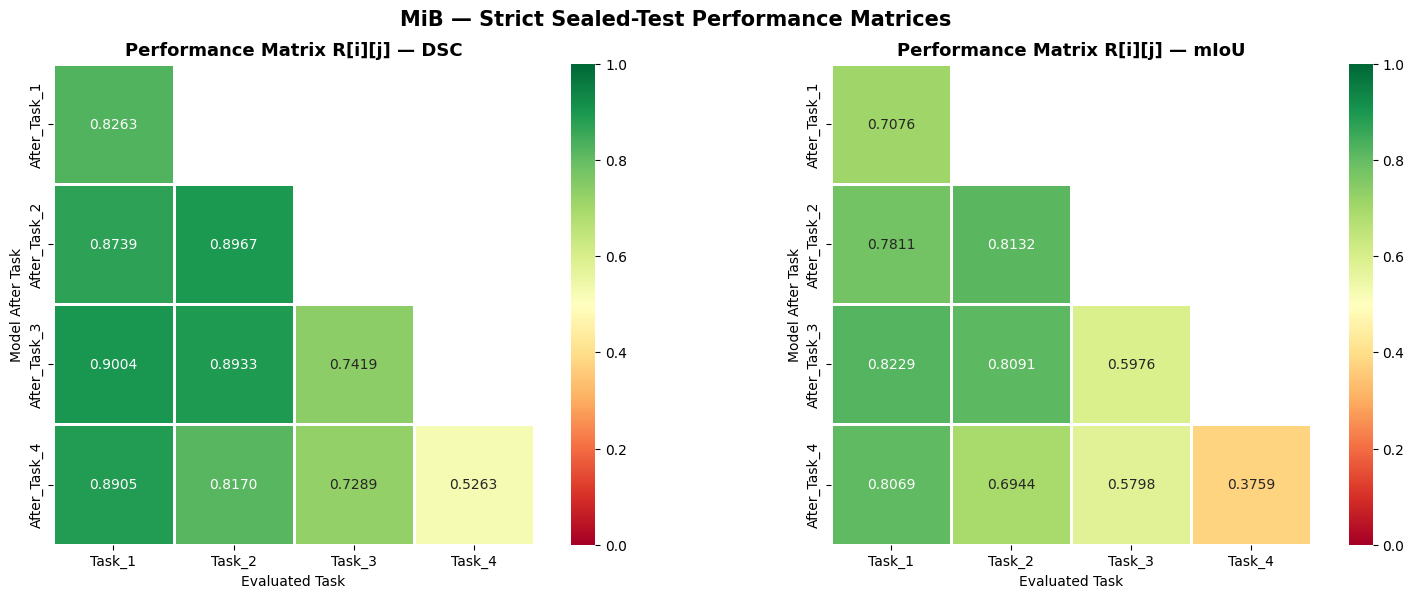


✓ Saved matrix visualization:
data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mib_strict_R_matrices.png

STRICT PERFORMANCE MATRIX ARTIFACTS COMPLETE
JSON  : data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mib_strict_metrics.json
CSV   : data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mib_R_matrix_DSC.csv
CSV   : data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mib_R_matrix_mIoU.csv
PLOT  : data/Multi-Atlas_Labeling_Beyond_the_Cranial_Vault/logs_baseline/mib_strict_R_matrices.png


In [ ]:
######################################################################
# PATCH — SAVE + VISUALIZE STRICT DSC & mIoU PERFORMANCE MATRICES
######################################################################\
# ============================================================
# STRICT mIoU MATRIX
# ============================================================
import pandas as pd
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt

def compute_strict_miou_matrix(
    checkpoint_dir,
    test_records,
    images_dir,
    masks_dir,
    device,
    task_organ_map,
    organ_names,
    split_checksum,
    config_hash,
    num_tasks=4,
    num_classes=14,
    encoder="resnet34",
    ignore_index=255,
    batch_size=16,
    num_workers=2,
):

    R_iou = np.full((num_tasks, num_tasks), np.nan)

    test_loader = DataLoader(
        BTCVDataset(
            test_records,
            images_dir,
            masks_dir,
            task_id=None,
            augment=False
        ),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False,
    )

    def get_ckpt_path(tid):

        candidates = []

        if tid == 1:
            candidates.append(f"{checkpoint_dir}/task1_best.pth")

        candidates += [
            f"{checkpoint_dir}/mib_task{tid}_best_cil.pth",
            f"{checkpoint_dir}/mib_task{tid}_best.pth",
        ]

        for p in candidates:
            if os.path.exists(p):
                return p

        return None

    for i in range(1, num_tasks + 1):

        ckpt_path = get_ckpt_path(i)

        if ckpt_path is None:
            continue

        ckpt = torch.load(
            ckpt_path,
            map_location="cpu",
            weights_only=False
        )

        model = build_unet(
            num_classes=num_classes,
            encoder=encoder,
            pretrained=None
        ).to(device)

        model.load_state_dict(ckpt["model_state"])
        model.eval()

        learned_organs = [
            o for t in range(1, i + 1)
            for o in task_organ_map[t]
        ]

        inter = defaultdict(float)
        pred_sum = defaultdict(float)
        true_sum = defaultdict(float)

        with torch.no_grad():

            for ct_batch, mask_batch in test_loader:

                ct_batch = ct_batch.to(device, non_blocking=True)
                mask_batch = mask_batch.to(device, non_blocking=True)

                with torch.amp.autocast(
                    'cuda',
                    enabled=(device.type == 'cuda')
                ):
                    logits = model(ct_batch)

                pred = torch.argmax(logits, dim=1)

                valid = (mask_batch != ignore_index)

                for oid in learned_organs:

                    pred_o = ((pred == oid) & valid)
                    true_o = ((mask_batch == oid) & valid)

                    inter[oid] += (
                        pred_o & true_o
                    ).sum().item()

                    pred_sum[oid] += pred_o.sum().item()
                    true_sum[oid] += true_o.sum().item()

        for j in range(1, i + 1):

            organs_j = task_organ_map[j]

            ious_j = []

            for oid in organs_j:

                union = (
                    pred_sum[oid]
                    + true_sum[oid]
                    - inter[oid]
                )

                if union > 0:

                    iou = inter[oid] / union
                    ious_j.append(iou)

            if len(ious_j) > 0:
                R_iou[i - 1, j - 1] = np.mean(ious_j)

        del model, ckpt
        force_cleanup()

    return R_iou


######################################################################
# COMPUTE STRICT MATRICES
######################################################################

metrics_dsc = print_and_compute_cil_metrics(
    R_dsc_strict,
    metric_name="DSC"
)

R_iou_strict = compute_strict_miou_matrix(
    checkpoint_dir = CHECKPOINT_DIR,
    test_records   = test_records_all,
    images_dir     = IMAGES_2D_DIR,
    masks_dir      = MASKS_2D_DIR,
    device         = DEVICE,
    task_organ_map = TASK_ORGANS,
    organ_names    = ORGAN_NAMES,
    split_checksum = SPLIT_CHECKSUM,
    config_hash    = CONFIG_HASH,
    num_tasks      = 4,
    num_classes    = TRAIN_CFG["num_classes"],
    encoder        = TRAIN_CFG["encoder"],
    ignore_index   = IGNORE_INDEX,
    batch_size     = TRAIN_CFG["batch_size"],
    num_workers    = TRAIN_CFG["num_workers"],
)

metrics_iou = print_and_compute_cil_metrics(
    R_iou_strict,
    metric_name="mIoU"
)


######################################################################
# SAVE JSON
######################################################################

strict_out = {
    "method": "CanonicalLwF",
    "eval_split": "sealed_test",
    "split_checksum": SPLIT_CHECKSUM,
    "config_hash": CONFIG_HASH,

    "R_dsc": R_dsc_strict.tolist(),
    "R_iou": R_iou_strict.tolist(),

    "metrics_dsc": metrics_dsc,
    "metrics_iou": metrics_iou,
}

strict_json = Path(LOG_DIR) / "mib_strict_metrics.json"

with open(strict_json, "w") as f:
    json.dump(strict_out, f, indent=2)

print(f"\n✓ Saved JSON:")
print(strict_json)


######################################################################
# SAVE CSV
######################################################################

df_dsc = pd.DataFrame(
    R_dsc_strict,
    index=[f"After_Task_{i}" for i in range(1,5)],
    columns=[f"Task_{j}" for j in range(1,5)]
)

df_iou = pd.DataFrame(
    R_iou_strict,
    index=[f"After_Task_{i}" for i in range(1,5)],
    columns=[f"Task_{j}" for j in range(1,5)]
)

csv_dsc = Path(LOG_DIR) / "mib_R_matrix_DSC.csv"
csv_iou = Path(LOG_DIR) / "mib_R_matrix_mIoU.csv"

df_dsc.to_csv(csv_dsc)
df_iou.to_csv(csv_iou)

print(f"✓ Saved CSV DSC : {csv_dsc}")
print(f"✓ Saved CSV IoU : {csv_iou}")


######################################################################
# VISUALIZATION — SIDE-BY-SIDE MATRICES
######################################################################

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ============================================================
# DSC
# ============================================================

sns.heatmap(
    df_dsc,
    annot=True,
    fmt=".4f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=1,
    ax=axes[0]
)

axes[0].set_title(
    "Performance Matrix R[i][j] — DSC",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Evaluated Task")
axes[0].set_ylabel("Model After Task")


# ============================================================
# mIoU
# ============================================================

sns.heatmap(
    df_iou,
    annot=True,
    fmt=".4f",
    cmap="RdYlGn",
    vmin=0,
    vmax=1,
    square=True,
    linewidths=1,
    ax=axes[1]
)

axes[1].set_title(
    "Performance Matrix R[i][j] — mIoU",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Evaluated Task")
axes[1].set_ylabel("Model After Task")

plt.suptitle(
    "MiB — Strict Sealed-Test Performance Matrices",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

matrix_path = Path(LOG_DIR) / "mib_strict_R_matrices.png"

plt.savefig(
    matrix_path,
    dpi=220,
    bbox_inches='tight'
)

plt.show()

print(f"\n✓ Saved matrix visualization:")
print(matrix_path)


######################################################################
# FINAL SUMMARY
######################################################################

print("\n" + "="*70)
print("STRICT PERFORMANCE MATRIX ARTIFACTS COMPLETE")
print("="*70)

print(f"JSON  : {strict_json}")
print(f"CSV   : {csv_dsc}")
print(f"CSV   : {csv_iou}")
print(f"PLOT  : {matrix_path}")

print("="*70)